#  Name of the Contributor -

1. Mohammad Walihullah - 20230768
2. Tahiya Jahan Laboni - 20240943
3. Tomas Ribeiro - 20250526
4. Deepak Lakhani - 20231006


# Imported Libraries

In [3]:
# imports
import pandas as pd
import numpy as np
from sklearn.cluster import DBSCAN, KMeans, AgglomerativeClustering
from sklearn.decomposition import PCA
from sklearn.base import clone
from sklearn.metrics import silhouette_score
from sklearn.metrics import r2_score
from sklearn.neighbors import NearestNeighbors
from sklearn.manifold import TSNE

from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.cluster.hierarchy import dendrogram
import warnings
from matplotlib.cm import get_cmap



import numpy as np
import pandas as pd
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import pairwise_distances
import matplotlib.pyplot as plt


# Then use it in your code
cmap = get_cmap('viridis')

# Suppress specific FutureWarnings
warnings.simplefilter(action='ignore', category=FutureWarning)

/var/folders/_s/_rkc5yf52mjg60_cwkkrw5yc0000gn/T/ipykernel_2748/3663596329.py:29: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = get_cmap('viridis')


In [4]:
file_path = 'data/data_save_for_clustering.csv'
df = pd.read_csv(file_path)

# Finding the heads of the dataframe for data understanding


---



In [7]:
df.head(3)

,vendor_count,product_count,is_chain,total orders,Orders on Weekend,Orders on week,Orders in the morning,Orders in the afternoon,Orders in night,American Cuisine,...,Asian_ratio,European_ratio,Snacks_Beverages_ratio,Other_Cuisine_ratio,avg_vendor_use,last_promo_DISCOUNT,last_promo_FREEBIE,last_promo_No Discount,payment_method_CASH,payment_method_DIGI
0,-0.406527,-0.012147,-0.530502,1,0.620842,-1.037124,-0.730228,0.066005,-0.543077,-0.443473,...,1.508620,-0.389688,-0.566452,-0.580573,-1.183705,0.0,0.0,0.0,0.0,1.0
1,-0.406527,-0.635255,-0.179832,1,0.620842,-1.037124,0.433980,-0.783958,-0.543077,0.799132,...,-0.184508,-0.389688,-0.566452,-0.580573,1.173853,1.0,0.0,0.0,0.0,1.0
2,-0.839745,-0.635255,-0.179832,1,0.620842,-1.037124,0.433980,-0.783958,-0.543077,0.448256,...,-1.028430,-0.389688,-0.566452,-0.580573,-0.790779,1.0,0.0,0.0,1.0,0.0


In [8]:
print(df.columns)


Index(['vendor_count', 'product_count', 'is_chain', 'total orders',
       'Orders on Weekend', 'Orders on week', 'Orders in the morning',
       'Orders in the afternoon', 'Orders in night', 'American Cuisine',
       'Asian Cuisine', 'European Cuisine', 'Snacks & Beverages',
       'Other Cuisine', 'total_amount_spent', 'order_frequency', 'age_group',
       'frequency_segment', 'American_ratio', 'Asian_ratio', 'European_ratio',
       'Snacks_Beverages_ratio', 'Other_Cuisine_ratio', 'avg_vendor_use',
       'last_promo_DISCOUNT', 'last_promo_FREEBIE', 'last_promo_No Discount',
       'payment_method_CASH', 'payment_method_DIGI'],
      dtype='object')


# Dividing the features by Metric and Non-metric Features

In [10]:
metric_features = [
 'vendor_count',
 'product_count',
 'is_chain',
 'Orders on Weekend',
 'Orders on week',
 'Orders in the morning',
 'Orders in the afternoon',
 'Orders in night',
 'American Cuisine',
 'Asian Cuisine',
 'European Cuisine',
 'Snacks & Beverages',
 'Other Cuisine',
 'total_amount_spent',
 'order_frequency',
 'American_ratio',
 'Asian_ratio',
 'European_ratio',
 'Snacks_Beverages_ratio',
 'Other_Cuisine_ratio',
 'avg_vendor_use']

non_metric_features = [
    'last_promo_DISCOUNT',
    'last_promo_FREEBIE',
    'last_promo_No Discount',
    'payment_method_CASH',
    'payment_method_DIGI',
    'age_group',
    'frequency_segment'
]

## Feature Extraction

### Features Splitting

In [13]:
df_metric_features = df[metric_features].copy()
df_non_metric_features = df[non_metric_features].copy()

## Dividing the features according to feature selection processs for Clustering

In [15]:
behavioral_features = [
    'Orders on Weekend','Orders on week','Orders in the morning',
    'Orders in the afternoon','Orders in night','order_frequency','avg_vendor_use']

Food_preferences_features = [
    'American Cuisine','Asian Cuisine','European Cuisine',
    'Snacks & Beverages','Other Cuisine'
]

Expenditure_features = [
    'total_amount_spent','American_ratio','Asian_ratio',
    'European_ratio','Snacks_Beverages_ratio','Other_Cuisine_ratio'
]

Order_features = [
    'vendor_count','product_count','is_chain'
]


In [16]:
behavior_features = df[behavioral_features].copy()
Food_preferences_features = df[Food_preferences_features].copy()
Expenditure_features = df[Expenditure_features].copy()
Order_features = df[Order_features].copy()

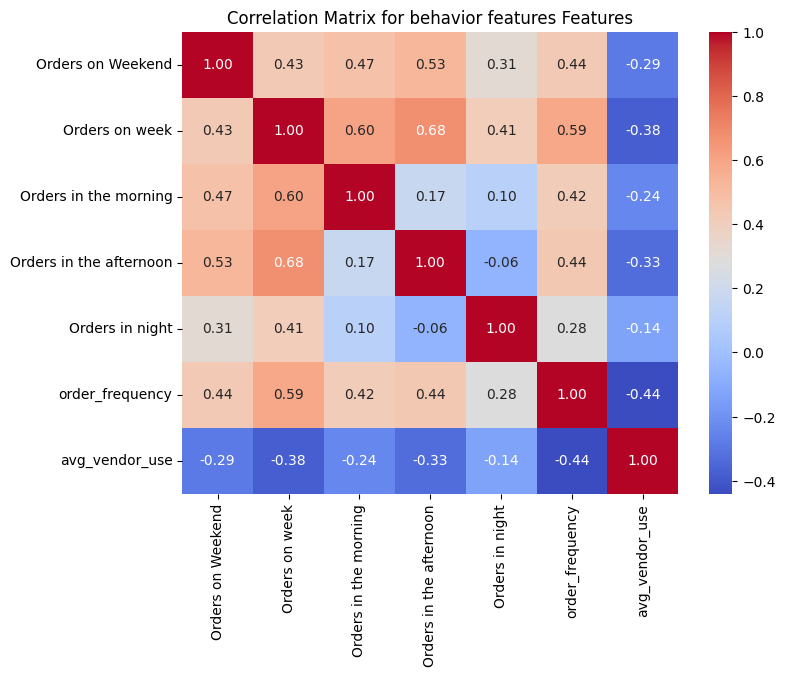

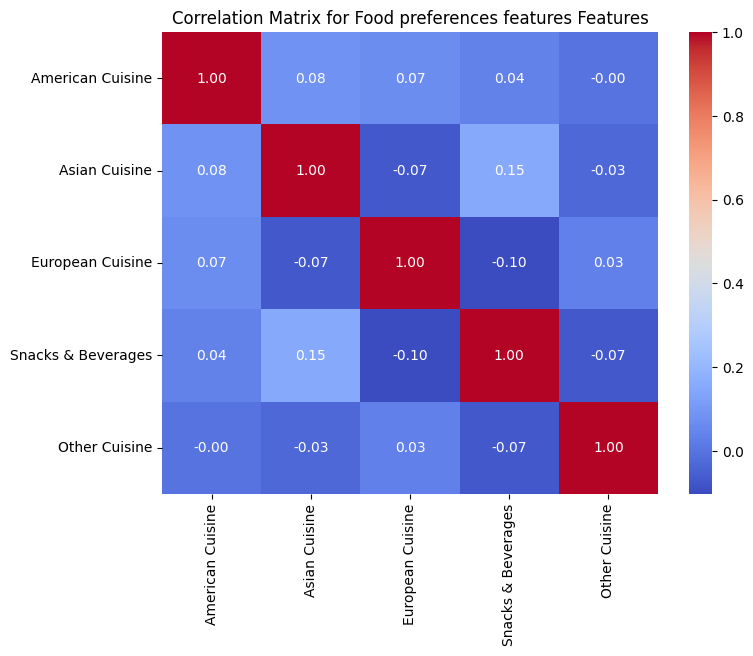

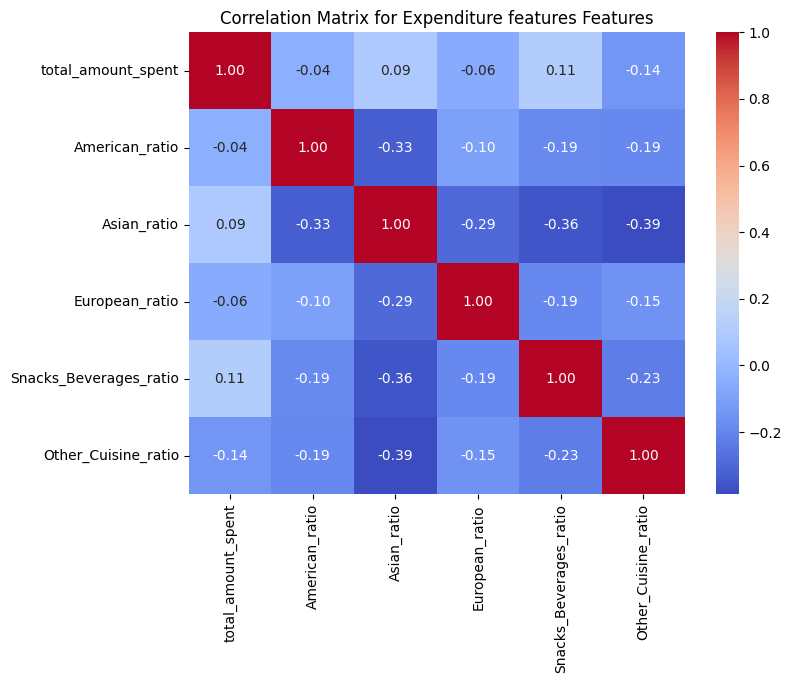

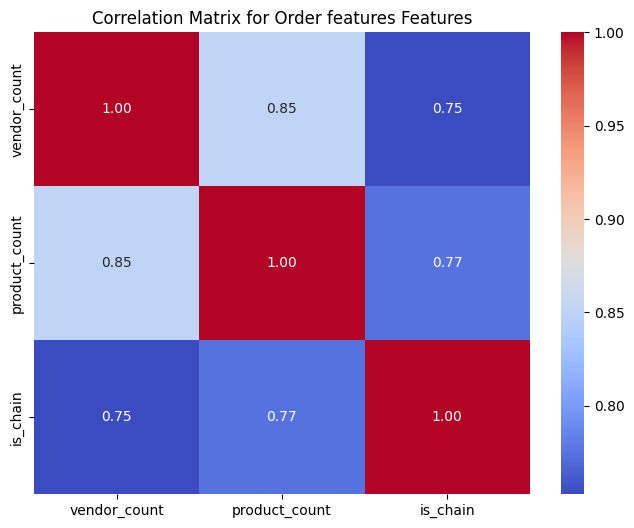

In [17]:
for segment_name, features in {
    "behavior features": behavior_features,
    "Food preferences features": Food_preferences_features,
    "Expenditure features": Expenditure_features,
    "Order features": Order_features,
}.items():
    # Ensure features are numeric
    valid_features = [col for col in features if col in df.select_dtypes(include=['number']).columns]
    if not valid_features:
        print(f"No numeric features for {segment_name}. Skipping...")
        continue

    # Calculate correlation matrix
    correlation_matrix = df[valid_features].corr()

    # Plot correlation heatmap
    plt.figure(figsize=(8, 6))
    plt.title(f"Correlation Matrix for {segment_name} Features")
    sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f")
    plt.show()


### <span style="color:salmon">Comparative Analysis of K-Means and Hierarchical Clustering Using $R^2$ Metrics</span>

In [19]:
def get_ss(df):
    ss = np.sum(df.var() * (df.count() - 1))
    return ss

#### $R^2$ Calculate

In [21]:
def get_r2(df, labels):
    sst = get_ss(df)
    ssw = np.sum(df.groupby(labels).apply(get_ss))
    return 1 - ssw/sst

In [22]:
def get_ss_variables(df):
    """
    Get the Sum of Squares (SS) for each variable.
    """
    if isinstance(df, np.ndarray):
        df = pd.DataFrame(df)

    ss_vars = df.var() * (df.count() - 1)
    return ss_vars

def r2_variables(df, labels):
    """
    Get the R² for each variable.
    """
    sst_vars = get_ss_variables(df)
    ssw_vars = np.sum(df.groupby(labels).apply(get_ss_variables))
    return 1 - ssw_vars/sst_vars

In [23]:
def get_r2_scores(df, cluster, min_k=1, max_k=10):
    r2_cluster = {}
    for i in range(min_k,max_k):
        cluster = clone(cluster).set_params(n_clusters=i)
        labels = cluster.fit_predict(df)
        r2_cluster[i] = get_r2(df, labels)
    return r2_cluster

In [24]:
def kmeans_FS(df):
    # Set up the clusterer
    kmeans = KMeans(
        n_clusters=2000,
        init='k-means++',
        n_init=10,
        random_state=42
    )

    # Get cluster labels
    km_labels = kmeans.fit_predict(df)

    # Dataframe to put the labels on
    kmeans_df = df.copy()

    # Create a new column 'CONTROLN' with cluster labels
    kmeans_df['CONTROLN'] = km_labels

    # Get the centroids of each cluster given by K-means
    kmeans_2000 = kmeans_df.groupby('CONTROLN').mean()

    return kmeans_2000

### Now, Find the best linkage method

In [26]:
def r2_plot(df):
    r2_scores = {}

    hierarchical = AgglomerativeClustering(metric='euclidean')

    # Doing hierarchical on top of the K-means
    for linkage in ['complete', 'average', 'single', 'ward']:
        r2_scores[linkage] = get_r2_scores(
            df, hierarchical.set_params(linkage=linkage)
        )

    # Visualizing the R² scores for each cluster solution
    pd.DataFrame(r2_scores).plot.line(figsize=(10,7))

    plt.title("R² plot for various clustering methods\n", fontsize=21)
    plt.legend(title="Cluster methods", title_fontsize=11)
    plt.xlabel("Number of clusters", fontsize=13)
    plt.ylabel("R² metric", fontsize=13)
    plt.show()

#### Comprehensive Clustering Analysis: Feature Evaluation, Correlation Analysis, R² Contributions, and Performance Visualization

In [28]:
def calculate_and_plot_silhouette(X, n_clusters_list, linkage):
    silhouette_scores = []

    for n_clusters in n_clusters_list:
        # Perform clustering
        clustering_model = AgglomerativeClustering(n_clusters=n_clusters, linkage=linkage)
        cluster_labels = clustering_model.fit_predict(X)

        # Calculate silhouette score
        score = silhouette_score(X, cluster_labels)
        silhouette_scores.append(score)

    # Plot silhouette scores
    plt.figure(figsize=(8, 6))
    plt.plot(n_clusters_list, silhouette_scores, marker='o', linestyle='-')
    plt.title("Silhouette Scores for Different Clustering Configurations")
    plt.xlabel("Number of Clusters")
    plt.ylabel("Silhouette Score")
    plt.xticks(n_clusters_list)
    plt.grid(True)
    plt.show()

    return silhouette_scores

# Compare clustering with and without feature

In [30]:
def compare_clustering_with_and_without_feature(data, feature_to_drop, n_clusters):
    # Original dataset
    df_original = pd.DataFrame(data)

    # Dataset without the specified feature
    df_without_feature = df_original.drop(columns=[feature_to_drop])

    # Clustering with original data
    kmeans_original = KMeans(n_clusters=n_clusters, random_state=42)
    labels_original = kmeans_original.fit_predict(df_original)

    silhouette_original = silhouette_score(df_original, labels_original)

    # Clustering without the specified feature
    kmeans_without_feature = KMeans(n_clusters=n_clusters, random_state=42)
    labels_without_feature = kmeans_without_feature.fit_predict(df_without_feature)

    silhouette_without_feature = silhouette_score(df_without_feature, labels_without_feature)

    # Display the performance comparison
    performance_comparison = pd.DataFrame({
        "Scenario": [f"With {feature_to_drop}", f"Without {feature_to_drop}"],
        "Silhouette Score": [silhouette_original, silhouette_without_feature]
    })
    print(performance_comparison)

    # Plotting the comparison for better visualization
    plt.figure(figsize=(8, 5))
    cmap = get_cmap('viridis')
    plt.bar(
        performance_comparison["Scenario"],
        performance_comparison["Silhouette Score"],
        color=[cmap(0.2), cmap(0.5)]
    )
    plt.title("Clustering Performance Comparison", fontsize=14)
    plt.ylabel("Silhouette Score", fontsize=12)
    plt.xlabel("Scenario", fontsize=12)
    plt.tight_layout()
    plt.show()

# Clustering and visualizations

In [32]:
def clustering_and_visualization(data, feature_to_drop, n_clusters):
    # Original data
    df_original = pd.DataFrame(data)
    df_without_feature = df_original.drop(columns=[feature_to_drop])

    # Clustering on original data
    kmeans_original = KMeans(n_clusters=n_clusters, random_state=42)
    labels_original = kmeans_original.fit_predict(df_original)

    # Clustering without the specified feature
    kmeans_without_feature = KMeans(n_clusters=n_clusters, random_state=42)
    labels_without_feature = kmeans_without_feature.fit_predict(df_without_feature)

    # Silhouette scores
    silhouette_original = silhouette_score(df_original, labels_original)
    silhouette_without_feature = silhouette_score(df_without_feature, labels_without_feature)

    # Performance comparison DataFrame
    performance_comparison = pd.DataFrame({
        "Scenario": [f"With {feature_to_drop}", f"Without {feature_to_drop}"],
        "Silhouette Score": [silhouette_original, silhouette_without_feature]
    })

    print("Performance Comparison:\n", performance_comparison)

    # PCA for visualization
    pca = PCA(n_components=2)
    data_original_pca = pca.fit_transform(df_original)
    data_without_feature_pca = pca.fit_transform(df_without_feature)

    # Visualization
    plt.figure(figsize=(14, 6))

    # Original data plot
    plt.subplot(1, 2, 1)
    plt.scatter(data_original_pca[:, 0], data_original_pca[:, 1],
                c=labels_original, cmap='viridis', s=50, alpha=0.7)
    plt.title(f"Clustering with {feature_to_drop}")
    plt.xlabel("PCA Component 1")
    plt.ylabel("PCA Component 2")

    # Data without the specified feature
    plt.subplot(1, 2, 2)
    plt.scatter(data_without_feature_pca[:, 0], data_without_feature_pca[:, 1],
                c=labels_without_feature, cmap='viridis', s=50, alpha=0.7)
    plt.title(f"Clustering without {feature_to_drop}")
    plt.xlabel("PCA Component 1")
    plt.ylabel("PCA Component 2")

    plt.tight_layout()
    plt.show()

    return performance_comparison

# Correlation analysis

In [34]:
def analyze_correlation(data, threshold=0.8):
    # Compute the correlation matrix
    correlation_matrix = data.corr()

    # Extract the upper triangle of the correlation matrix
    upper_triangle = correlation_matrix.where(
        np.triu(np.ones(correlation_matrix.shape), k=1).astype(bool)
    )

    # Find features with correlation above the threshold
    redundant_pairs = [
        (column, index)
        for index, row in upper_triangle.iterrows()
        for column, value in row.items()
        if abs(value) > threshold
    ]

    # Output redundant pairs
    print("Highly correlated feature pairs (above threshold):")
    print(redundant_pairs)

    # Visualize the correlation matrix using a heatmap
    plt.figure(figsize=(8, 6))
    sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f")
    plt.title("Correlation Matrix")
    plt.show()

    return redundant_pairs

# R-square contributions of features

In [36]:
def analyze_r2_contributions(r2_contributions, low_impact_threshold=0.1):
    # Convert R^2 contributions to a DataFrame
    r2_df = pd.DataFrame(
        list(r2_contributions.items()), columns=["Feature", "R^2 Contribution"]
    ).sort_values(by="R^2 Contribution", ascending=False)

    # Identify low-impact features
    low_impact_features = r2_df[r2_df["R^2 Contribution"] < low_impact_threshold]

    # Display the results
    print("Low-Impact Features for Potential Removal:")
    print(low_impact_features)

    # Visualize the contributions
    plt.figure(figsize=(8, 5))
    sns.barplot(data=r2_df, x="R^2 Contribution", y="Feature", palette="viridis")
    plt.axvline(x=low_impact_threshold, color="red", linestyle="--", label="Low-Impact Threshold")
    plt.title("Feature Contributions to R^2 Metric")
    plt.xlabel("R^2 Contribution")
    plt.ylabel("Feature")
    plt.legend()
    plt.tight_layout()
    plt.show()

    return low_impact_features

### <span style="color:salmon">1. Behavior  Features analysis </span>

In [39]:
# k-means on behavior_features
kmeans_2000_behavior = kmeans_FS(behavior_features)
kmeans_2000_behavior

,Orders on Weekend,Orders on week,Orders in the morning,Orders in the afternoon,Orders in night,order_frequency,avg_vendor_use
CONTROLN,,,,,,,
0,0.620842,1.134060,3.026990,-0.629419,0.174903,1.045051,-0.797866
1,-0.808900,-0.660590,-0.730228,-0.364719,-0.543077,-0.343483,-0.790779
2,1.335713,0.722117,-0.397597,1.705220,0.380040,1.042843,-1.488778
3,-0.094029,-1.037124,-0.730228,-0.358976,-0.543077,-1.662000,1.173853
4,-0.094029,-0.091754,-0.109317,-0.585633,0.892882,0.910110,1.173853
...,...,...,...,...,...,...,...
1995,0.620842,0.615496,2.762397,-0.601823,-0.543077,0.877736,-0.195011
1996,-0.094029,-0.189005,1.016085,-0.783958,-0.543077,1.032690,0.197490
1997,-0.094029,0.968677,1.670952,0.119128,-0.453330,1.031917,0.615453


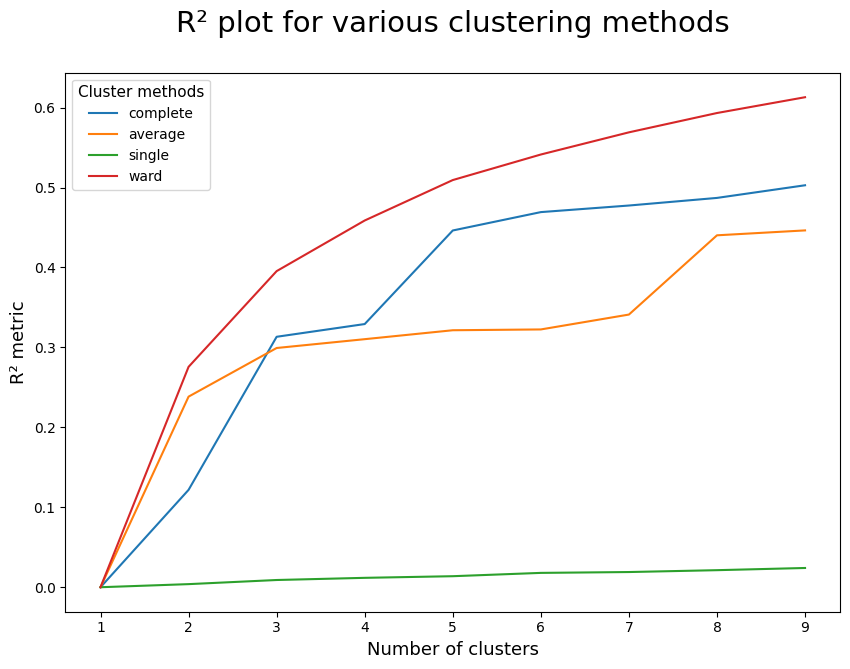

In [40]:
r2_plot(kmeans_2000_behavior)

**Recommendation:**
- Ward's method achieves the most effective clustering for this dataset.
- Keep 4 clusters based on the elbow method.

In [42]:
hclust_behavior_features = AgglomerativeClustering(
    linkage='ward', metric='euclidean', n_clusters=4)

hclust_labels_behavior_features = hclust_behavior_features.fit_predict(kmeans_2000_behavior)
kmeans_2000_behavior['h_labels'] = hclust_labels_behavior_features
df_merge_behaior = kmeans_2000_behavior.merge(pd.Series(hclust_labels_behavior_features,
                                                                name='h_labels',
                                                                index=kmeans_2000_behavior.index),on='h_labels')


In [43]:
# Assuming r2_variables returns a DataFrame with 'h_labels' as a column or index
result_behavior_features = r2_variables(df_merge_behaior, 'h_labels')
sorted_result_behavior = result_behavior_features.drop('h_labels').sort_values(ascending=False)
print(sorted_result_behavior)

Orders on week             0.591848
Orders in the afternoon    0.451552
Orders in night            0.329955
Orders in the morning      0.281894
Orders on Weekend          0.243423
order_frequency            0.160479
avg_vendor_use             0.090173
dtype: float64


/var/folders/_s/_rkc5yf52mjg60_cwkkrw5yc0000gn/T/ipykernel_2748/2461973775.py:16: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  ssw_vars = np.sum(df.groupby(labels).apply(get_ss_variables))


# Correlation matrix of the behavior features

Highly correlated feature pairs (above threshold):
[]


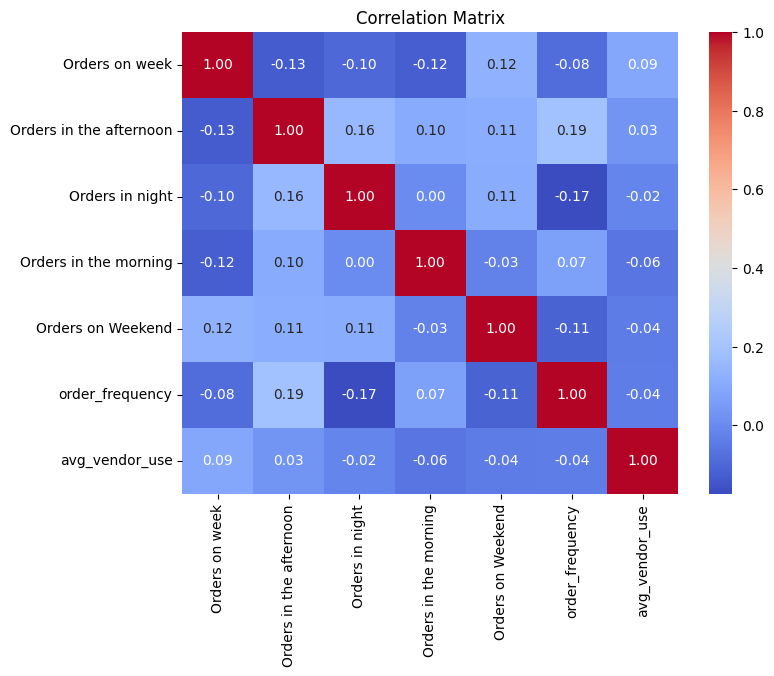

In [45]:
# Example usage
data = {
    "Orders on week": np.random.rand(100),
    "Orders in the afternoon": np.random.rand(100),
    "Orders in night": np.random.rand(100),
    "Orders in the morning": np.random.rand(100),
    "Orders on Weekend": np.random.rand(100),
    "order_frequency": np.random.rand(100),
    "avg_vendor_use": np.random.rand(100),
}
df_value = pd.DataFrame(data)

# Call the function
redundant_features = analyze_correlation(df_value, threshold=0.8)



**Key Observations from correlation and R square:**
- Correlation Matrix:
There are no highly correlated features (above 0.8 threshold). The highest correlation is -0.22, which is far below the typical threshold for dropping features.
- Redundancy Check:
there are no redundant feature pairs above the set threshold (0.8).
- R² Feature Importance:
All features have some level of importance, with `Orders on week` being the most significant (R² = 0.591848) and `avg_vendor_use` being the least significant (R² = 0.090173).

**Let's insure how many cluster would be best**

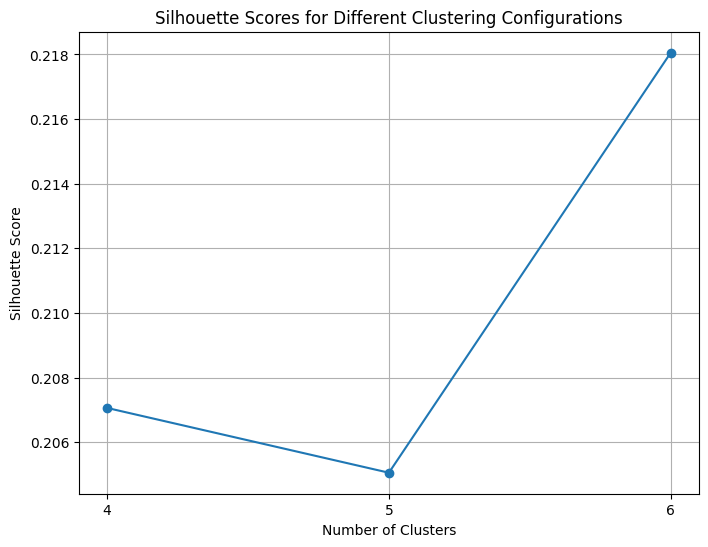

Number of Clusters: 4, Silhouette Score: 0.2071
Number of Clusters: 5, Silhouette Score: 0.2051
Number of Clusters: 6, Silhouette Score: 0.2181


In [48]:
# Define your dataset and cluster numbers
X = behavior_features
n_clusters_list = [4, 5, 6]  # Specify the cluster numbers to evaluate

# Call the function
silhouette_scores = calculate_and_plot_silhouette(X, n_clusters_list, linkage="ward")

# Print the silhouette scores
for n_clusters, score in zip(n_clusters_list, silhouette_scores):
    print(f"Number of Clusters: {n_clusters}, Silhouette Score: {score:.4f}")

In [49]:
hclust_behavior_features = AgglomerativeClustering(
    linkage='ward', metric='euclidean', n_clusters=6)

hclust_labels_behavior_features = hclust_behavior_features.fit_predict(kmeans_2000_behavior)
kmeans_2000_behavior['h_labels'] = hclust_labels_behavior_features
df_merge_behaior = kmeans_2000_behavior.merge(pd.Series(hclust_labels_behavior_features,
                                                                name='h_labels',
                                                                index=kmeans_2000_behavior.index),on='h_labels')
# Assuming r2_variables returns a DataFrame with 'h_labels' as a column or index
result_behavior_features = r2_variables(df_merge_behaior, 'h_labels')
sorted_result_behavior = result_behavior_features.drop('h_labels').sort_values(ascending=False)
print(sorted_result_behavior)

Orders on week             0.579422
Orders in the afternoon    0.522367
Orders in the morning      0.417191
Orders in night            0.242450
Orders on Weekend          0.238356
order_frequency            0.111039
avg_vendor_use             0.065872
dtype: float64


/var/folders/_s/_rkc5yf52mjg60_cwkkrw5yc0000gn/T/ipykernel_2748/2461973775.py:16: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  ssw_vars = np.sum(df.groupby(labels).apply(get_ss_variables))


**Use 6 clusters as it provides a better balance of explained variance across multiple features.**

### <span style="color:salmon">2. Food Preferences Features analysis based on K-means and R-square
 Features </span>

In [53]:
# k-means on cuisine_features
kmeans_2000_cuisine = kmeans_FS(Food_preferences_features)
kmeans_2000_cuisine

,American Cuisine,Asian Cuisine,European Cuisine,Snacks & Beverages,Other Cuisine
CONTROLN,,,,,
0,-0.431418,-0.621497,-0.349688,-0.188289,-0.451101
1,0.854821,-0.034225,0.371880,-0.424440,-0.455182
2,-0.431971,-0.085109,-0.336450,-0.406646,3.764705
3,-0.432886,1.240835,-0.352038,5.769348,-0.455182
4,-0.443473,1.628051,-0.344445,-0.441285,-0.452771
...,...,...,...,...,...
1995,-0.443473,0.875825,-0.352038,0.668821,3.777031
1996,-0.443473,0.159505,0.549259,-0.044417,2.075563
1997,6.835752,1.670854,-0.352038,1.869420,-0.455182


# R-Square matrix for the food preferences features

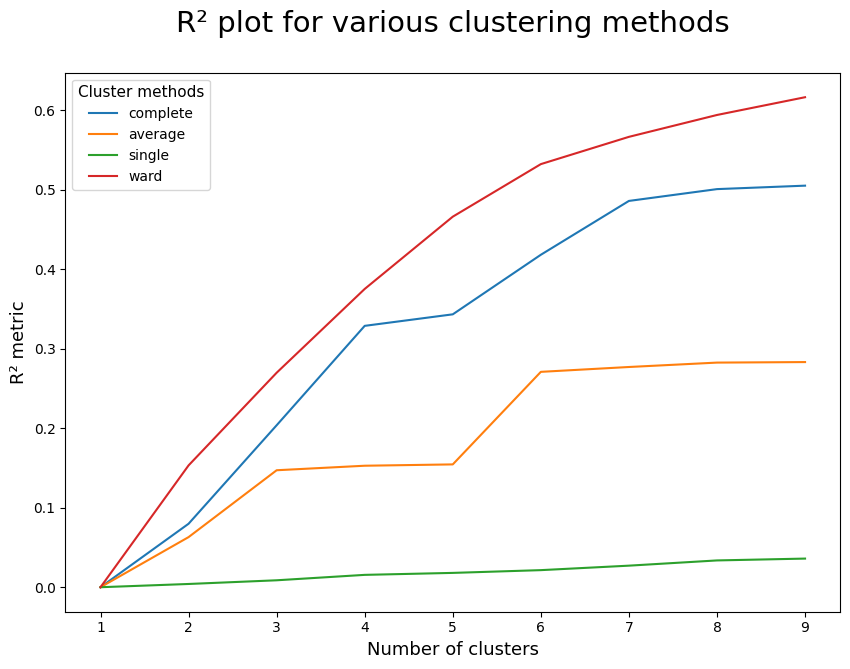

In [55]:
# Data behavior Perspective
r2_plot(kmeans_2000_cuisine)

**Recommendation:**
- Ward's method achieves the most effective clustering for this dataset.
- Keep 4 clusters based on the elbow method.

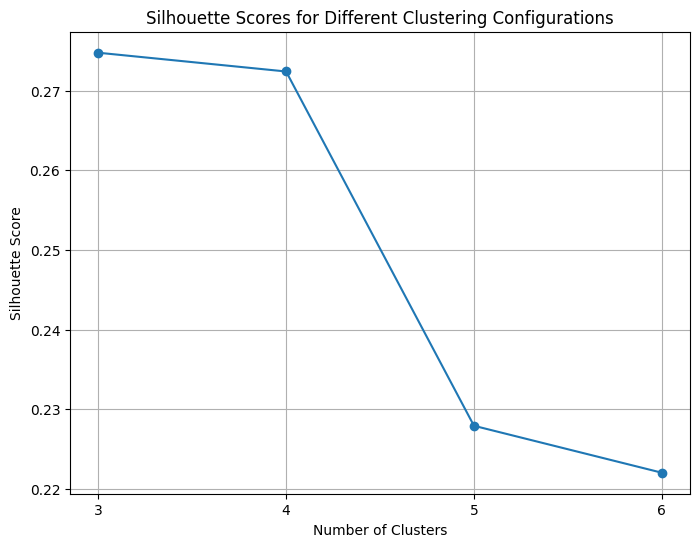

Number of Clusters: 3, Silhouette Score: 0.2748
Number of Clusters: 4, Silhouette Score: 0.2724
Number of Clusters: 5, Silhouette Score: 0.2279
Number of Clusters: 6, Silhouette Score: 0.2220


In [57]:
# Define your dataset and cluster numbers
X = kmeans_2000_cuisine
n_clusters_list = [3, 4, 5, 6]  # Specify the cluster numbers to evaluate

# Call the function
silhouette_scores = calculate_and_plot_silhouette(X, n_clusters_list, linkage="ward")

# Print the silhouette scores
for n_clusters, score in zip(n_clusters_list, silhouette_scores):
    print(f"Number of Clusters: {n_clusters}, Silhouette Score: {score:.4f}")

In [58]:
hclust_cuisine_features = AgglomerativeClustering(
    linkage='ward', metric='euclidean', n_clusters=4)

hclust_labels_cuisine_features = hclust_cuisine_features.fit_predict(kmeans_2000_cuisine)
kmeans_2000_cuisine['h_labels'] = hclust_labels_cuisine_features
df_merge_cuisine = kmeans_2000_cuisine.merge(pd.Series(hclust_labels_cuisine_features,
                                                                name='h_labels',
                                                                index=kmeans_2000_cuisine.index),on='h_labels')
# Assuming r2_variables returns a DataFrame with 'h_labels' as a column or index
result_cuisine = r2_variables(df_merge_cuisine, 'h_labels')
sorted_result_cuisine = result_cuisine.drop('h_labels').sort_values(ascending=False)
print(sorted_result_cuisine)


American Cuisine      0.458633
Other Cuisine         0.153605
Asian Cuisine         0.084307
European Cuisine      0.002157
Snacks & Beverages    0.001054
dtype: float64


/var/folders/_s/_rkc5yf52mjg60_cwkkrw5yc0000gn/T/ipykernel_2748/2461973775.py:16: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  ssw_vars = np.sum(df.groupby(labels).apply(get_ss_variables))


Highly correlated feature pairs (above threshold):
[]


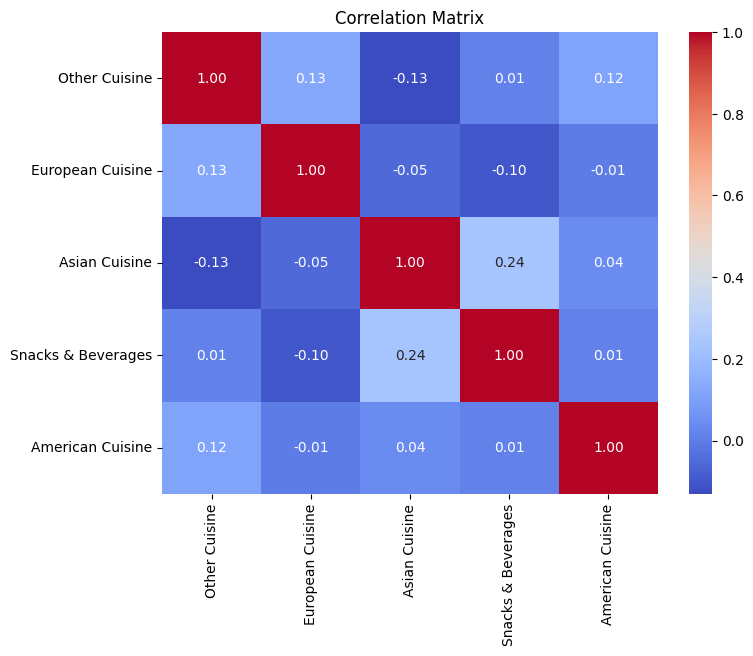

In [59]:
# Example usage
data = {
    "Other Cuisine": np.random.rand(100),
    "European Cuisine": np.random.rand(100),
    "Asian Cuisine": np.random.rand(100),
    "Snacks & Beverages": np.random.rand(100),
    "American Cuisine": np.random.rand(100)
}
df_cuisine_value = pd.DataFrame(data)

# Call the function
redundant_features = analyze_correlation(df_cuisine_value, threshold=0.8)



Low-Impact Features for Potential Removal:
              Feature  R^2 Contribution
3  Snacks & Beverages          0.023397
4    American Cuisine          0.011158


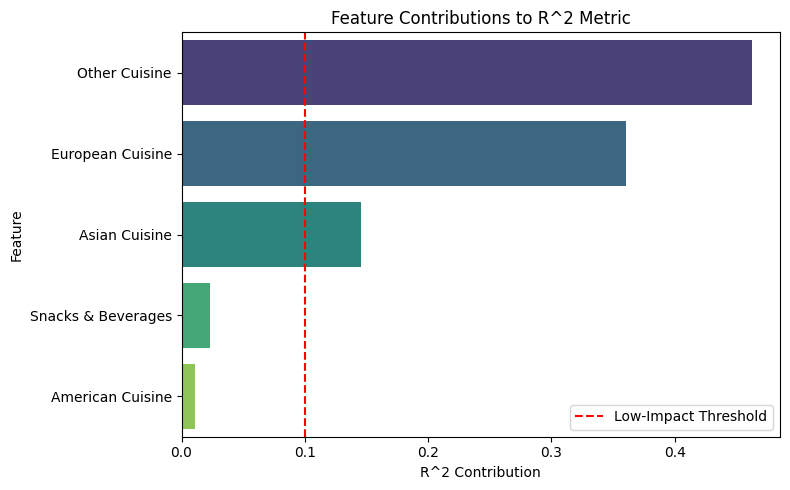

In [60]:
# Example usage
r2_contributions_cuisine_features = {
        "Other Cuisine": 0.462236,
        "European Cuisine": 0.360858,
        "Asian Cuisine": 0.145244,
        "Snacks & Beverages": 0.023397,
        "American Cuisine": 0.011158,
}

low_impact_features_cuisine_features = analyze_r2_contributions(r2_contributions_cuisine_features)

/var/folders/_s/_rkc5yf52mjg60_cwkkrw5yc0000gn/T/ipykernel_2748/759844139.py:29: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = get_cmap('viridis')


                   Scenario  Silhouette Score
0     With American Cuisine          0.195746
1  Without American Cuisine          0.224444


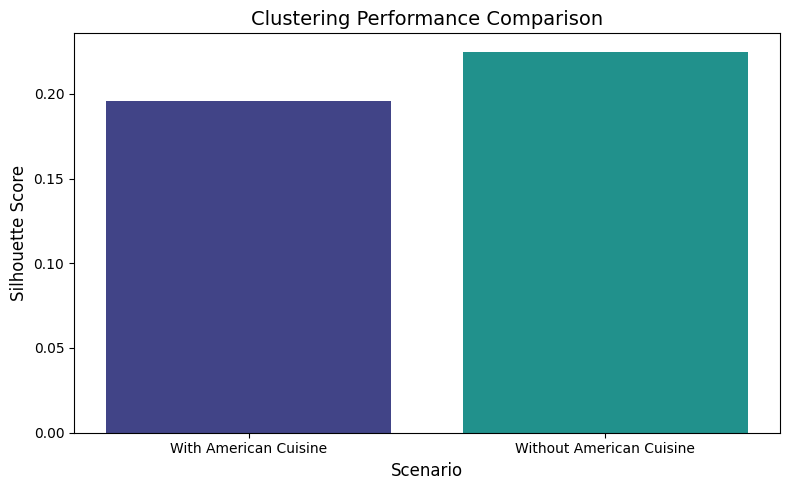

In [61]:
# Run the function to compare clustering with and without `order_frequency`
compare_clustering_with_and_without_feature(
    data=df_cuisine_value,  # Your dataset
    feature_to_drop='American Cuisine',  # Feature to exclude
    n_clusters=4  # Number of clusters
)

                     Scenario  Silhouette Score
0     With Snacks & Beverages          0.195746
1  Without Snacks & Beverages          0.249832


/var/folders/_s/_rkc5yf52mjg60_cwkkrw5yc0000gn/T/ipykernel_2748/759844139.py:29: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = get_cmap('viridis')


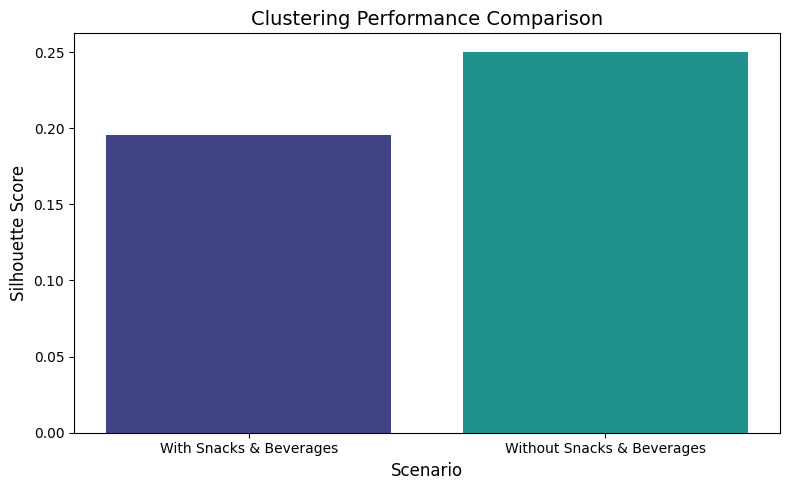

In [62]:
# Run the function to compare clustering with and without `order_frequency`
compare_clustering_with_and_without_feature(
    data=df_cuisine_value,  # Your dataset
    feature_to_drop='Snacks & Beverages',  # Feature to exclude
    n_clusters=4  # Number of clusters
)

Performance Comparison:
                    Scenario  Silhouette Score
0     With American Cuisine          0.195746
1  Without American Cuisine          0.224444


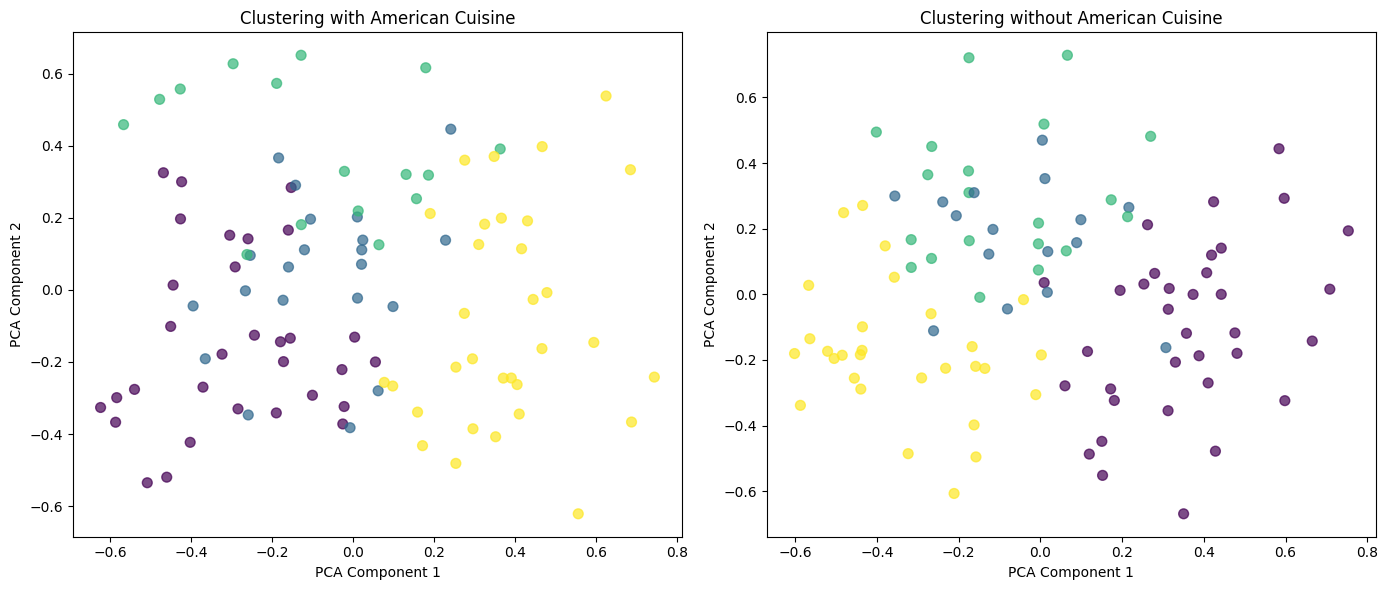

In [63]:
# Assuming `data` is your dataframe
comparison_results_American_Cuisinet = clustering_and_visualization(
    df_cuisine_value, "American Cuisine", 4)


Performance Comparison:
                      Scenario  Silhouette Score
0     With Snacks & Beverages          0.195746
1  Without Snacks & Beverages          0.249832


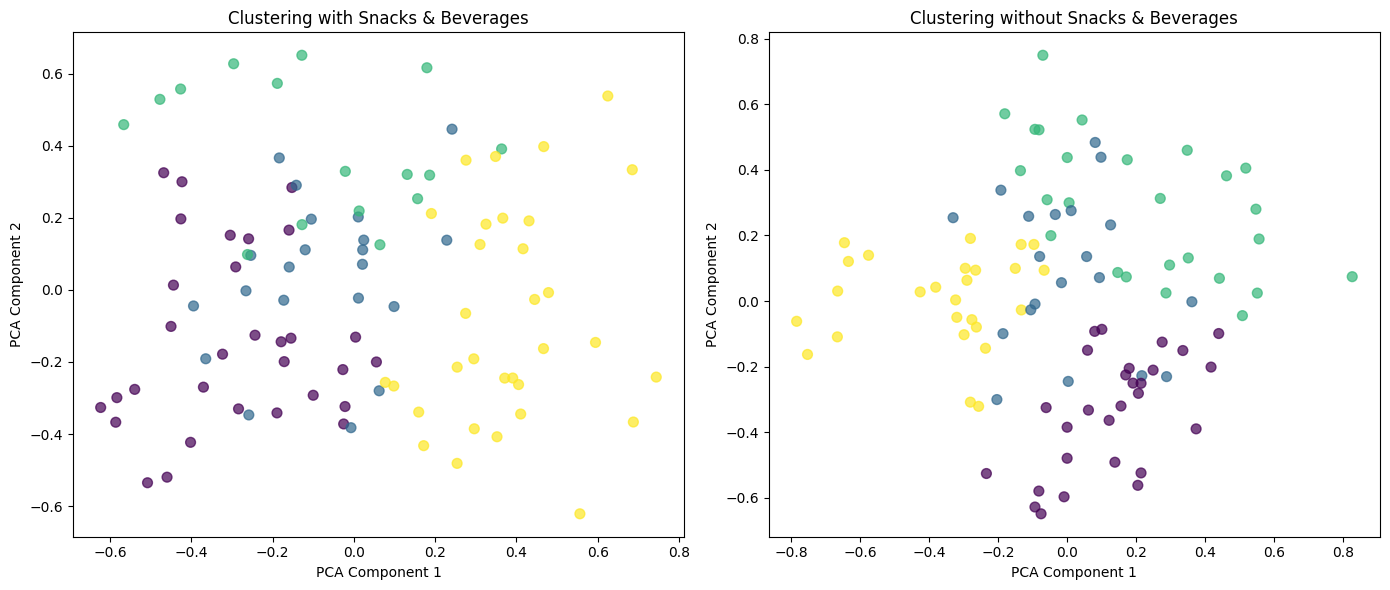

In [64]:
# Assuming `data` is your dataframe
comparison_results_American_Cuisinet = clustering_and_visualization(
    df_cuisine_value, "Snacks & Beverages", 4)

**I should drop `Snacks & Beverages` first because it has a more significant negative effect on clustering quality.**

In [66]:
# K-means on data_social without the 2 variables
kmeans_2000_cuisine_final = kmeans_FS(Food_preferences_features.drop(columns=['Snacks & Beverages']))

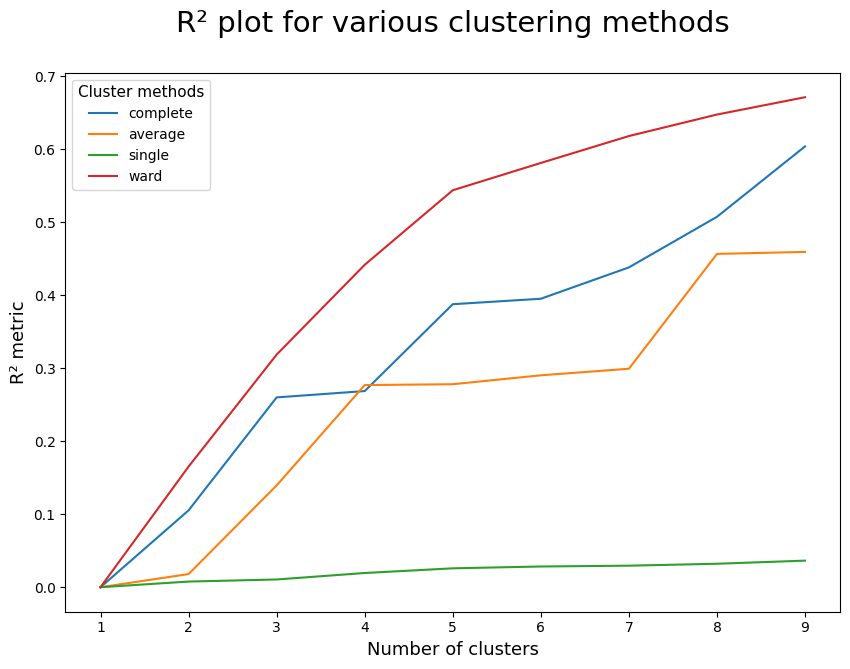

In [67]:
# Data socio_economic_features
r2_plot(kmeans_2000_cuisine_final)

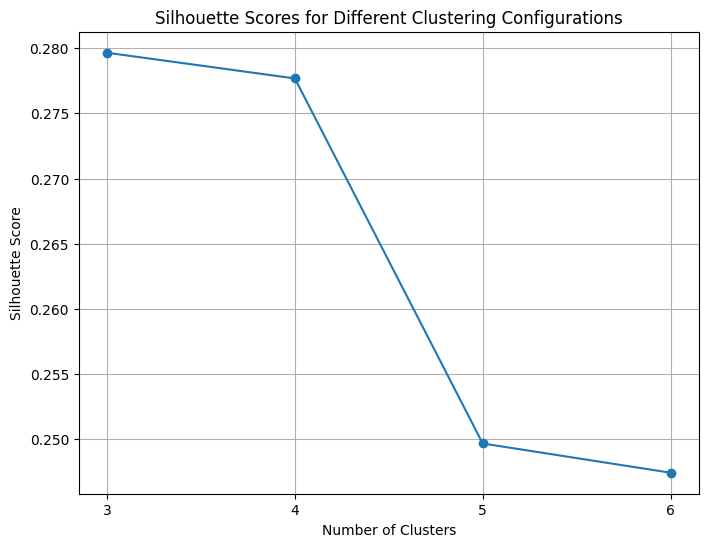

Number of Clusters: 3, Silhouette Score: 0.2797
Number of Clusters: 4, Silhouette Score: 0.2777
Number of Clusters: 5, Silhouette Score: 0.2497
Number of Clusters: 6, Silhouette Score: 0.2474


In [68]:
# Define your dataset and cluster numbers
X = kmeans_2000_cuisine_final
n_clusters_list = [3, 4, 5, 6]  # Specify the cluster numbers to evaluate

# Call the function
silhouette_scores = calculate_and_plot_silhouette(X, n_clusters_list, linkage="ward")

# Print the silhouette scores
for n_clusters, score in zip(n_clusters_list, silhouette_scores):
    print(f"Number of Clusters: {n_clusters}, Silhouette Score: {score:.4f}")

In [69]:
hclust_cuisine_features = AgglomerativeClustering(
    linkage='ward', metric='euclidean', n_clusters=4)

hclust_labels_cuisine_features = hclust_cuisine_features.fit_predict(kmeans_2000_cuisine_final)
kmeans_2000_cuisine_final['h_labels'] = hclust_labels_cuisine_features
df_merge_cuisine = kmeans_2000_cuisine_final.merge(pd.Series(hclust_labels_cuisine_features,
                                                                name='h_labels',
                                                                index=kmeans_2000_cuisine_final.index),on='h_labels')
# Assuming r2_variables returns a DataFrame with 'h_labels' as a column or index
result_cuisine = r2_variables(df_merge_cuisine, 'h_labels')
sorted_result_cuisine = result_cuisine.drop('h_labels').sort_values(ascending=False)
print(sorted_result_cuisine)


American Cuisine    0.484456
Other Cuisine       0.303531
Asian Cuisine       0.282272
European Cuisine    0.028520
dtype: float64


/var/folders/_s/_rkc5yf52mjg60_cwkkrw5yc0000gn/T/ipykernel_2748/2461973775.py:16: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  ssw_vars = np.sum(df.groupby(labels).apply(get_ss_variables))


### <span style="color:salmon">3. Expenditure/Spending Features Analysis based on K-means  </span>

In [71]:
# k-means on spending_features
kmeans_2000_spending = kmeans_FS(Expenditure_features)
kmeans_2000_spending

,total_amount_spent,American_ratio,Asian_ratio,European_ratio,Snacks_Beverages_ratio,Other_Cuisine_ratio
CONTROLN,,,,,,
0,0.833477,0.876465,-0.442283,0.649162,-0.566452,-0.159294
1,-0.300101,-0.505134,0.367027,-0.389688,0.008991,0.278554
2,-0.005258,0.009415,-1.028430,2.475106,-0.566452,-0.126432
3,-0.608507,-0.519555,-1.028430,-0.389688,2.657493,-0.580573
4,-0.445348,-0.519555,-1.028090,-0.387625,-0.566452,2.628202
...,...,...,...,...,...,...
1995,-0.064443,-0.519555,-0.004921,1.364908,-0.055282,-0.580573
1996,2.486142,1.199061,-1.028430,-0.389688,0.466708,0.105488
1997,0.555217,0.056686,-0.114828,-0.360191,0.483698,-0.097032


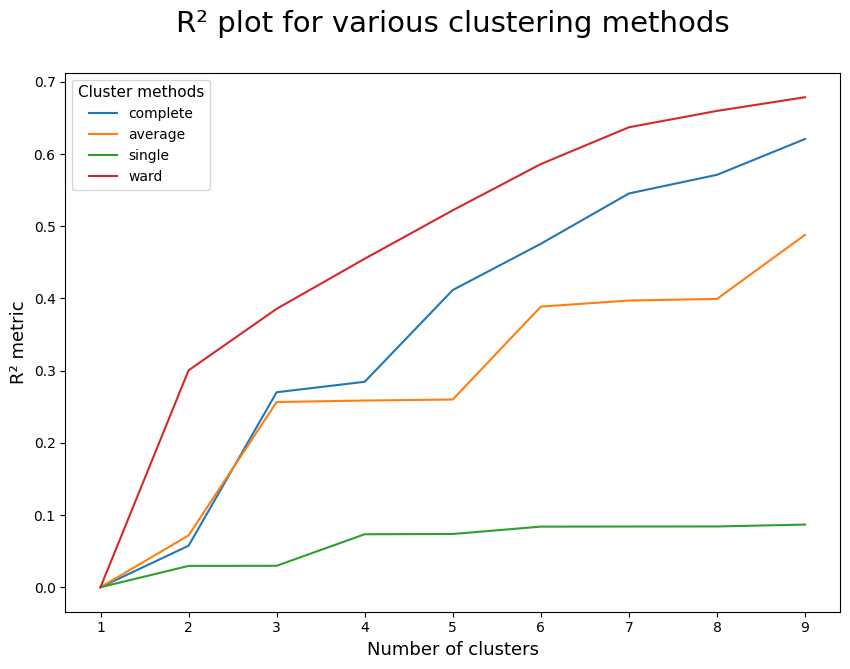

In [72]:
# Data convenience_features
r2_plot(kmeans_2000_spending)

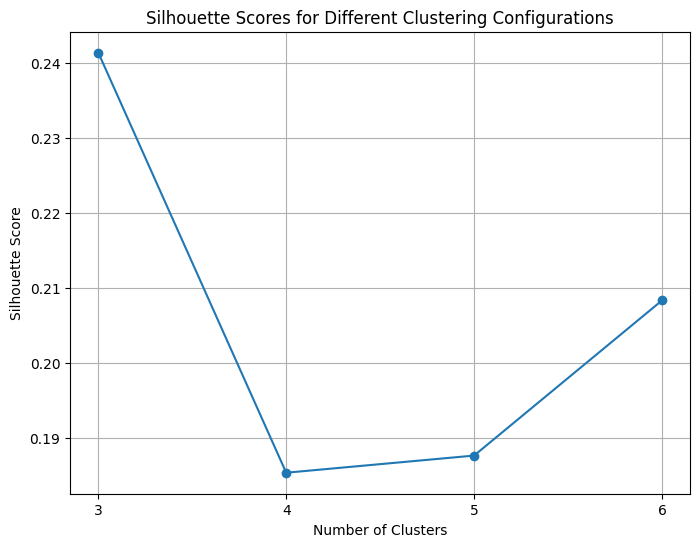

Number of Clusters: 3, Silhouette Score: 0.2414
Number of Clusters: 4, Silhouette Score: 0.1854
Number of Clusters: 5, Silhouette Score: 0.1877
Number of Clusters: 6, Silhouette Score: 0.2083


In [73]:
# Define your dataset and cluster numbers
X = kmeans_2000_spending
n_clusters_list = [3, 4, 5, 6]  # Specify the cluster numbers to evaluate

# Call the function
silhouette_scores = calculate_and_plot_silhouette(X, n_clusters_list, linkage="ward")

# Print the silhouette scores
for n_clusters, score in zip(n_clusters_list, silhouette_scores):
    print(f"Number of Clusters: {n_clusters}, Silhouette Score: {score:.4f}")

In [74]:
hclust_final_spending_features = AgglomerativeClustering(
    linkage='ward', metric='euclidean', n_clusters=4)

hclust_final_labels_spending_features = hclust_final_spending_features.fit_predict(kmeans_2000_spending)

kmeans_2000_spending['h_labels'] = hclust_final_labels_spending_features
df_merge_final_spending = kmeans_2000_spending.merge(pd.Series(hclust_final_labels_spending_features,
                                                                name='h_labels',
                                                                index=kmeans_2000_spending.index),on='h_labels')

# Assuming r2_variables returns a DataFrame with 'h_labels' as a column or index
final_result_spending = r2_variables(df_merge_final_spending, 'h_labels')
sorted_final_result_spending = final_result_spending.drop('h_labels').sort_values(ascending=False)
print(sorted_final_result_spending)


total_amount_spent        0.523312
Other_Cuisine_ratio       0.505234
European_ratio            0.433718
Asian_ratio               0.072098
American_ratio            0.048553
Snacks_Beverages_ratio    0.046540
dtype: float64


/var/folders/_s/_rkc5yf52mjg60_cwkkrw5yc0000gn/T/ipykernel_2748/2461973775.py:16: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  ssw_vars = np.sum(df.groupby(labels).apply(get_ss_variables))


# Correaltion matrix for the spending features

Highly correlated feature pairs (above threshold):
[]


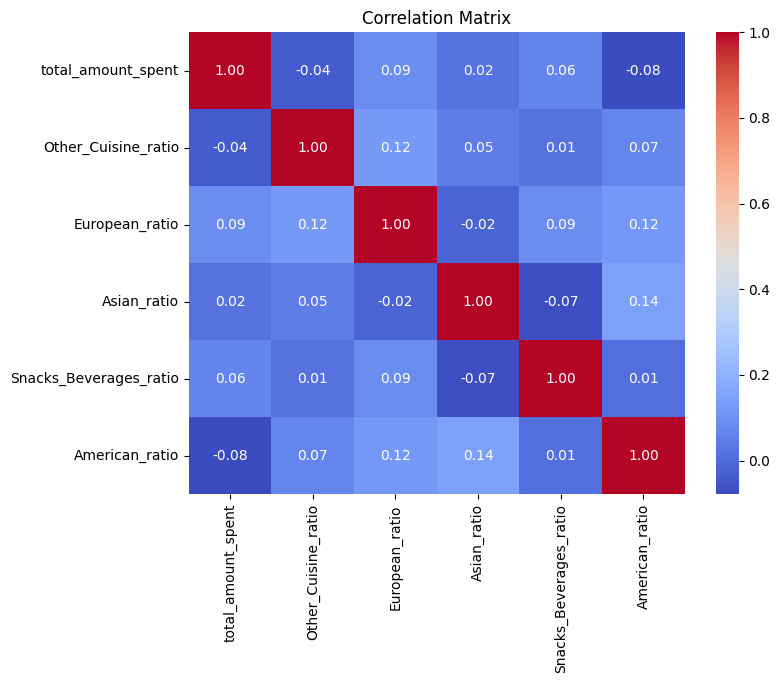

In [76]:
# Example usage
data = {
    "total_amount_spent": np.random.rand(100),
    "Other_Cuisine_ratio": np.random.rand(100),
    "European_ratio": np.random.rand(100),
    "Asian_ratio": np.random.rand(100),
    "Snacks_Beverages_ratio": np.random.rand(100),
    "American_ratio": np.random.rand(100)
}
df_spending_value = pd.DataFrame(data)

# Call the function
redundant_features = analyze_correlation(df_spending_value, threshold=0.8)



# Spending features contributions based on R-Square

Low-Impact Features for Potential Removal:
                  Feature  R^2 Contribution
3             Asian_ratio          0.072098
4  Snacks_Beverages_ratio          0.048553
5          American_ratio          0.046540


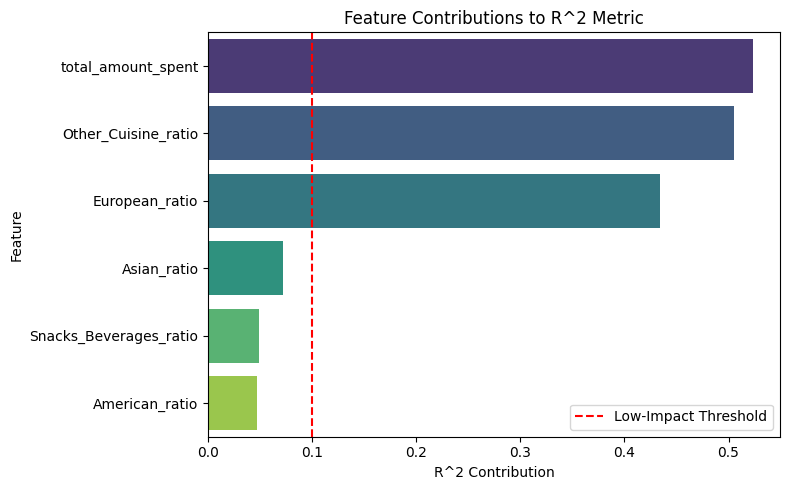

In [78]:
# Example usage
r2_contributions_spending_features = {
        "total_amount_spent":0.523312,
        "Other_Cuisine_ratio":0.505234,
        "European_ratio":0.433718,
        "Asian_ratio": 0.072098,
        "Snacks_Beverages_ratio": 0.048553,
        "American_ratio":0.046540,
}

low_impact_features_spending_features = analyze_r2_contributions(r2_contributions_spending_features)

# Comparison of the clusters with and without features

Performance Comparison:
                  Scenario  Silhouette Score
0     With American_ratio          0.153222
1  Without American_ratio          0.190364


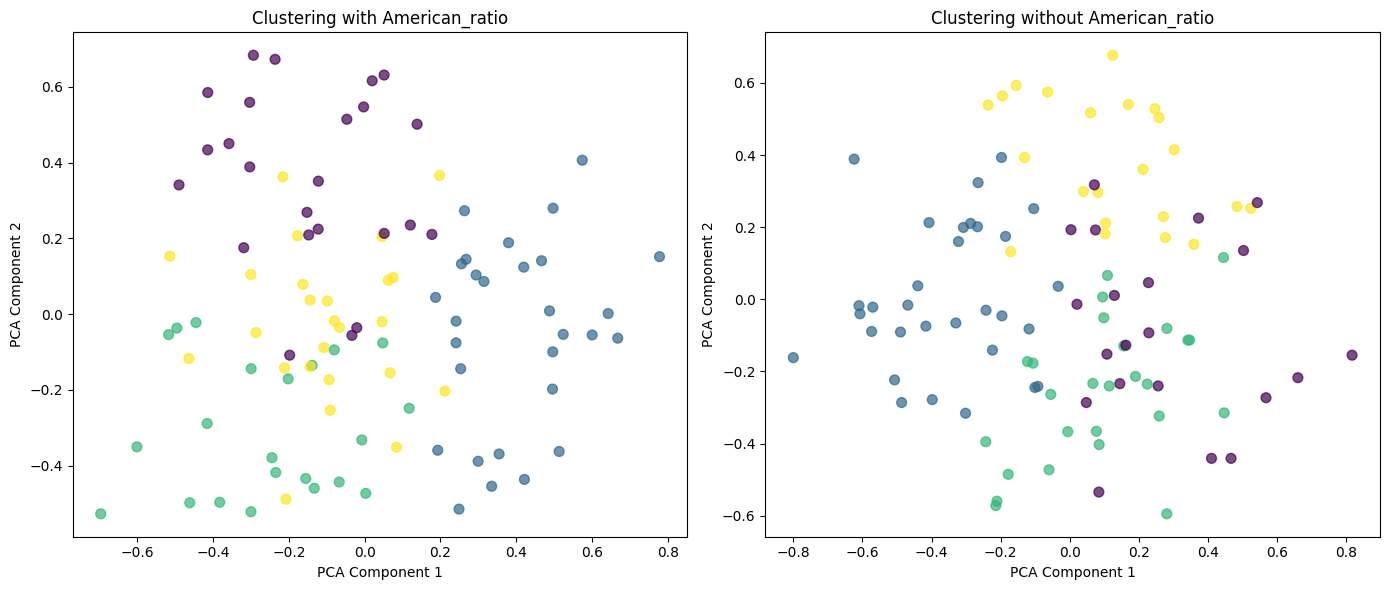

In [80]:
# Assuming `data` is your dataframe
comparison_results_American_Cuisinet = clustering_and_visualization(
    df_spending_value, "American_ratio", 4)


# Comparison the clusters with and without features

Performance Comparison:
                          Scenario  Silhouette Score
0     With Snacks_Beverages_ratio          0.153222
1  Without Snacks_Beverages_ratio          0.203821


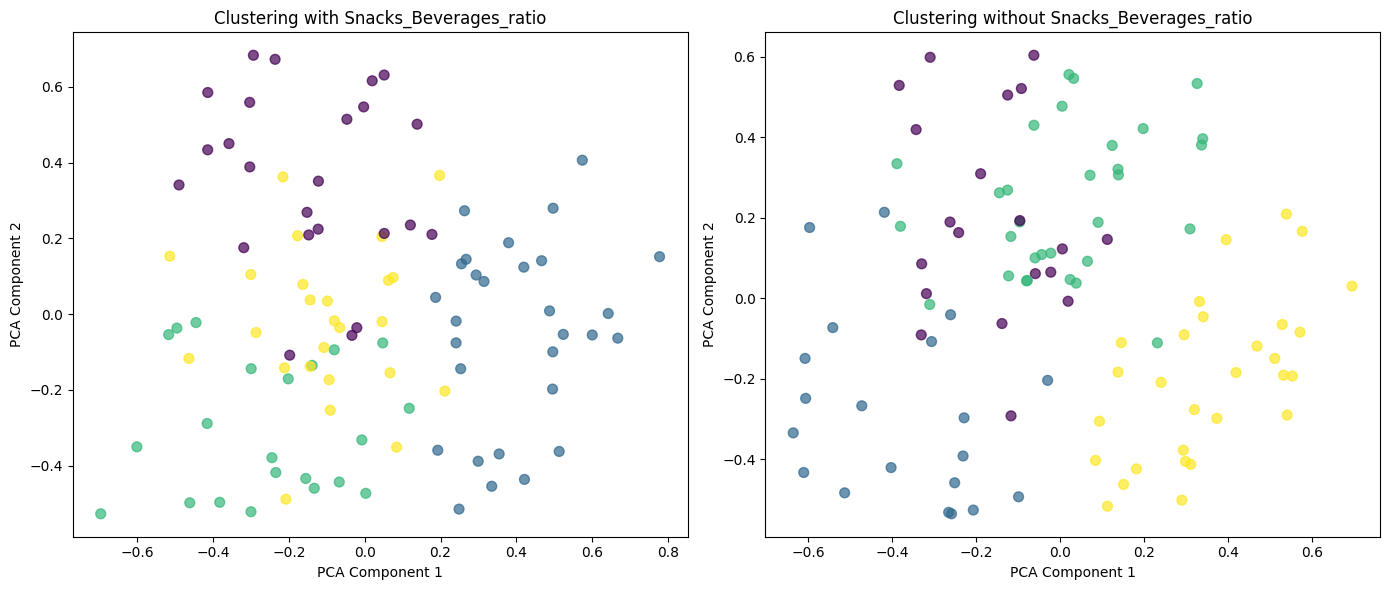

In [82]:
# Assuming `data` is your dataframe
comparison_results_American_Cuisinet = clustering_and_visualization(
    df_spending_value, "Snacks_Beverages_ratio", 4)


                 Scenario  Silhouette Score
0     With American_ratio          0.153222
1  Without American_ratio          0.190364


/var/folders/_s/_rkc5yf52mjg60_cwkkrw5yc0000gn/T/ipykernel_2748/759844139.py:29: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = get_cmap('viridis')


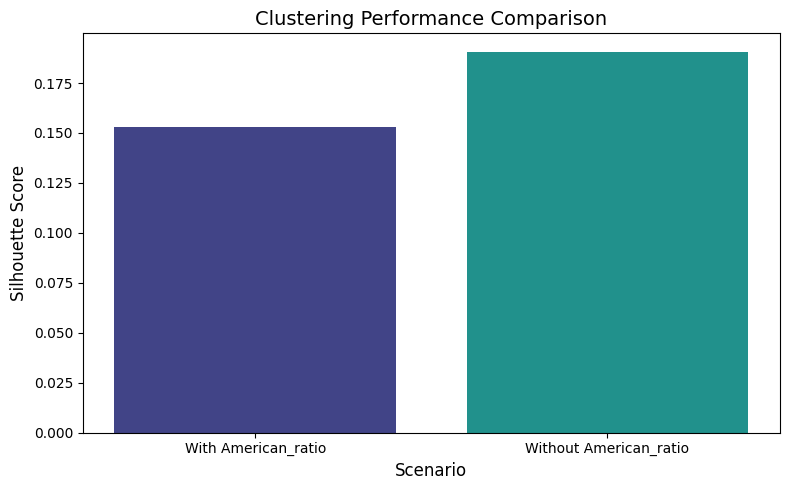

In [83]:
# Run the function to compare clustering with and without `order_frequency`
compare_clustering_with_and_without_feature(
    data=df_spending_value,  # Your dataset
    feature_to_drop='American_ratio',  # Feature to exclude
    n_clusters=4  # Number of clusters
)

                         Scenario  Silhouette Score
0     With Snacks_Beverages_ratio          0.153222
1  Without Snacks_Beverages_ratio          0.203821


/var/folders/_s/_rkc5yf52mjg60_cwkkrw5yc0000gn/T/ipykernel_2748/759844139.py:29: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = get_cmap('viridis')


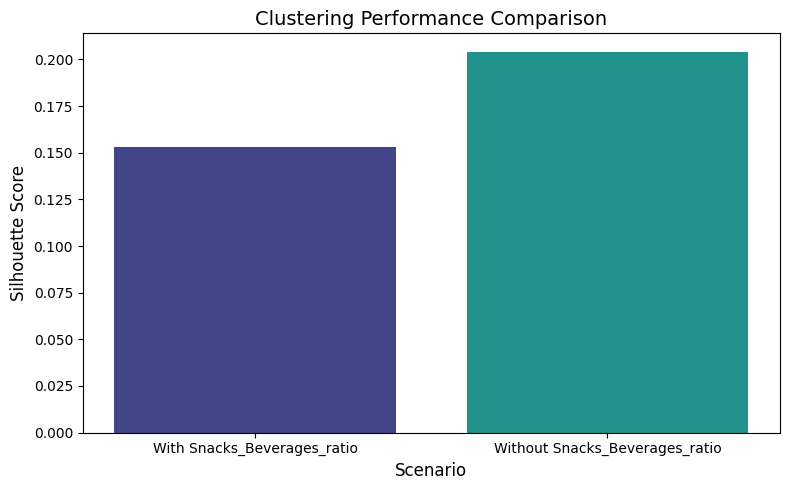

In [84]:
# Run the function to compare clustering with and without `order_frequency`
compare_clustering_with_and_without_feature(
    data=df_spending_value,  # Your dataset
    feature_to_drop='Snacks_Beverages_ratio',  # Feature to exclude
    n_clusters=4  # Number of clusters
)

### <span style="color:salmon">4. Vendor  Features analysis based on k-means</span>

In [86]:
# k-means on vendor_features
kmeans_2000_vendor = kmeans_FS(Order_features)
kmeans_2000_vendor

/opt/anaconda3/lib/python3.12/site-packages/sklearn/base.py:1474: ConvergenceWarning: Number of distinct clusters (1933) found smaller than n_clusters (2000). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)


,vendor_count,product_count,is_chain
CONTROLN,,,
0,-0.406527,-0.219850,-0.179832
1,2.625996,2.272581,2.976199
2,0.459908,0.818663,1.222848
3,0.459908,0.610960,-0.530502
4,-0.406527,-0.635255,-0.530502
...,...,...,...
1928,3.925648,3.934201,1.573519
1929,3.492431,3.934201,3.677539
1930,5.225301,6.426632,6.132231


# Vendor features analysis based on R-Square

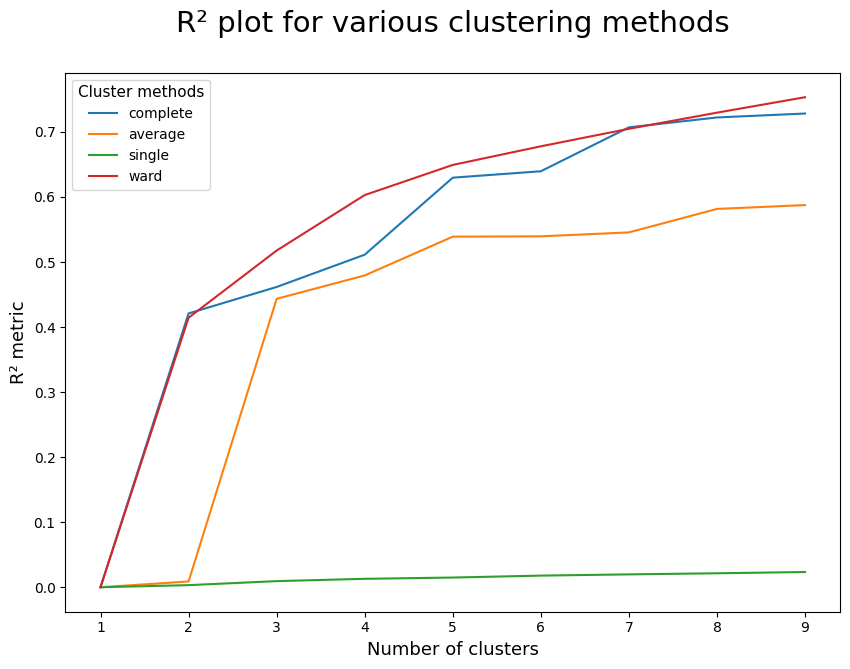

In [88]:
# Data socio_economic_features
r2_plot(kmeans_2000_vendor)

# Silhouette Scores of the features

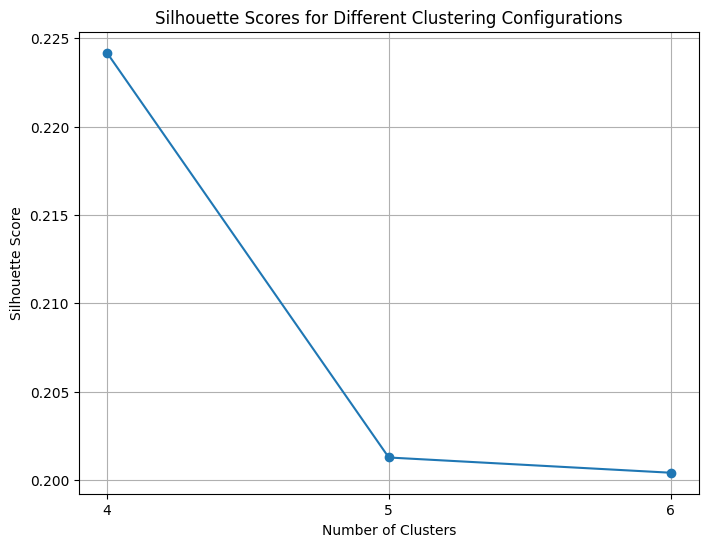

Number of Clusters: 4, Silhouette Score: 0.2242
Number of Clusters: 5, Silhouette Score: 0.2013
Number of Clusters: 6, Silhouette Score: 0.2004


In [90]:
# Define your dataset and cluster numbers
X = kmeans_2000_vendor
n_clusters_list = [4,5,6]  # Specify the cluster numbers to evaluate

# Call the function
silhouette_scores_socio_economic = calculate_and_plot_silhouette(X, n_clusters_list, linkage="ward")

# Print the silhouette scores
for n_clusters, score in zip(n_clusters_list, silhouette_scores_socio_economic):
    print(f"Number of Clusters: {n_clusters}, Silhouette Score: {score:.4f}")

In [91]:
hclust_final_vendor_features = AgglomerativeClustering(
    linkage='ward', metric='euclidean', n_clusters=4)

hclust_final_labels_vendor_features = hclust_final_vendor_features.fit_predict(kmeans_2000_vendor)

kmeans_2000_vendor['h_labels'] = hclust_final_labels_vendor_features
df_merge_final_vendor = kmeans_2000_vendor.merge(pd.Series(hclust_final_labels_vendor_features,
                                                                name='h_labels',
                                                                index=kmeans_2000_vendor.index),on='h_labels')

# Assuming r2_variables returns a DataFrame with 'h_labels' as a column or index
final_result_vendor = r2_variables(df_merge_final_vendor, 'h_labels')
sorted_final_result_vendor = final_result_vendor.drop('h_labels').sort_values(ascending=False)
print(sorted_final_result_vendor)


is_chain         0.676857
product_count    0.517000
vendor_count     0.446679
dtype: float64


/var/folders/_s/_rkc5yf52mjg60_cwkkrw5yc0000gn/T/ipykernel_2748/2461973775.py:16: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  ssw_vars = np.sum(df.groupby(labels).apply(get_ss_variables))


# Correlation analysis of the vendor features

Highly correlated feature pairs (above threshold):
[]


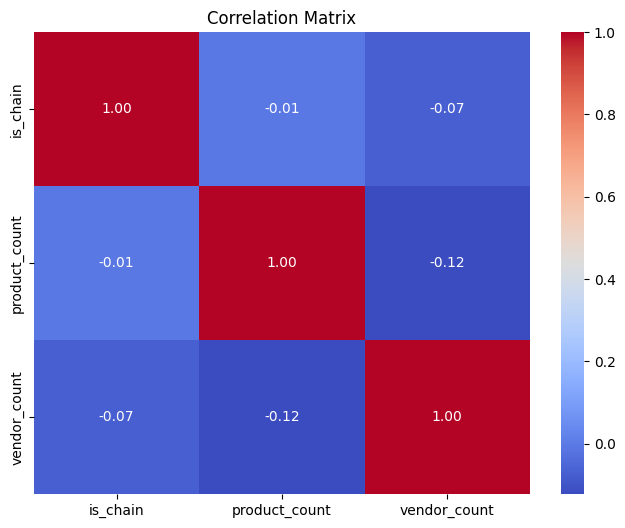

In [93]:
# Example usage
data = {
    "is_chain": np.random.rand(100),
    "product_count": np.random.rand(100),
    "vendor_count": np.random.rand(100),
}
df_vendor_value = pd.DataFrame(data)

# Call the function
redundant_features = analyze_correlation(df_vendor_value, threshold=0.8)



In [94]:
# Drop `Snacks & Beverages` feature into cuisine_features
Food_preferences_features = Food_preferences_features.drop(columns=['Snacks & Beverages'])

In [95]:
Food_preferences_features

,American Cuisine,Asian Cuisine,European Cuisine,Other Cuisine
0,-0.443473,0.546069,-0.352038,-0.455182
1,0.799132,-0.377496,-0.352038,-0.455182
2,0.448256,-0.639905,-0.352038,-0.455182
3,-0.443473,0.656124,-0.352038,-0.455182
4,0.968754,1.038445,-0.352038,-0.455182
...,...,...,...,...
31029,-0.443473,-0.639905,-0.352038,-0.455182
31030,1.305091,-0.639905,-0.352038,-0.455182
31031,-0.443473,-0.639905,-0.352038,-0.455182
31032,-0.443473,-0.145886,-0.352038,-0.455182


**Apply KMeans clustering**

In [97]:
# final Apply KMeans clustering
kmeans_behavior_features = KMeans(n_clusters=6, random_state=0).fit(behavior_features)
kmeans_Food_preferences_features = KMeans(n_clusters=4, random_state=0).fit(Food_preferences_features)
kmeans_Expenditure_features = KMeans(n_clusters=4, random_state=0).fit(Expenditure_features)
kmeans_Order_features = KMeans(n_clusters=4, random_state=0).fit(Order_features)

In [98]:
df_cluster = df.copy()

In [99]:
# Add cluster labels to the original DataFrame
df_cluster['behaviorCluster'] = kmeans_behavior_features.labels_
df_cluster['CuisineCluster'] = kmeans_Food_preferences_features.labels_
df_cluster['SpendingCluster'] = kmeans_Expenditure_features.labels_
df_cluster['VendorCluster'] = kmeans_Order_features.labels_

In [100]:
behavior_features = behavior_features.columns.tolist()
Food_preferences_features = Food_preferences_features.columns.tolist()
Expenditure_features = Expenditure_features.columns.tolist()
Order_features = Order_features.columns.tolist()

In [101]:
df_cluster.groupby('behaviorCluster')[behavior_features].mean()

,Orders on Weekend,Orders on week,Orders in the morning,Orders in the afternoon,Orders in night,order_frequency,avg_vendor_use
behaviorCluster,,,,,,,
0,-0.512223,-0.657125,-0.491215,-0.487736,-0.321710,-1.275444,1.162275
1,0.605342,0.766279,-0.027609,1.451859,-0.312989,0.878020,-0.809802
2,2.106454,2.508587,2.645976,1.983784,0.284477,1.075820,-0.917058
3,-0.400199,-0.462994,-0.404621,-0.315801,-0.245683,-0.328048,-0.822916
4,-0.057014,-0.083935,0.225982,-0.260825,-0.047419,0.600543,0.352646
5,0.889695,1.178789,0.298261,-0.215776,2.932881,0.917155,-0.568930


In [102]:
df_cluster.groupby('CuisineCluster')[Food_preferences_features].mean()

,American Cuisine,Asian Cuisine,European Cuisine,Other Cuisine
CuisineCluster,,,,
0,-0.226604,-0.127437,0.008227,-0.365972
1,-0.251800,-0.309099,-0.170428,1.082996
2,1.975257,1.355984,0.080434,-0.239319
3,0.101895,0.107671,0.459339,4.333158


In [103]:
df_cluster.groupby('SpendingCluster')[Expenditure_features].mean()

,total_amount_spent,American_ratio,Asian_ratio,European_ratio,Snacks_Beverages_ratio,Other_Cuisine_ratio
SpendingCluster,,,,,,
0,0.249648,-0.334728,-0.692638,-0.350141,1.920819,-0.464430
1,-0.257115,0.696154,-0.751905,-0.259844,-0.426855,0.979095
2,0.130396,-0.314491,1.074858,-0.299912,-0.412758,-0.435122
3,-0.199053,-0.297841,-0.840955,2.871383,-0.517326,-0.462841


In [104]:
df_cluster.groupby('VendorCluster')[Order_features].mean()

,vendor_count,product_count,is_chain
VendorCluster,,,
0,-0.584141,-0.559075,-0.526100
1,0.275513,0.199123,0.182764
2,3.221831,3.432786,3.435518
3,1.457343,1.457023,1.321350


# Contingency table for the combined clusters

In [107]:
# Create a contingency table for the combined clusters
contingency_table = pd.crosstab(
    index=df_cluster['behaviorCluster'],
    columns=[df_cluster['CuisineCluster'], df_cluster['SpendingCluster'], df_cluster['VendorCluster']],
    margins=True,  # Adds the row/column totals
    margins_name="Total"
)

contingency_table


CuisineCluster      0                                                ...    3  \
SpendingCluster     0                    1                  2        ...    1   
VendorCluster       0     1   2    3     0    1  2    3     0     1  ...    1   
behaviorCluster                                                      ...        
0                1216    44   0    0  1876   70  0    0  2888    57  ...    0   
1                  15   137   1  115    13   98  0   57   120   534  ...  101   
2                   1    11  29   64     0    0  2    7     1    21  ...   10   
3                1368   191   0    1   609   40  0    0  2597   256  ...   39   
4                 681   897   0   46   615  691  0   20  1542  1485  ...   45   
5                   6   135   8   98     1   28  1   16    32   229  ...    6   
Total            3287  1415  38  324  3114  927  3  100  7180  2582  ...  201   

CuisineCluster                                   Total  
SpendingCluster             2          3                
VendorCluster      2    3   1   2   3  1  2   3         
behaviorCluster                                         
0                  0    0   0   0   0  0  0   0   7489  
1                  7  114   4   5  14  7  1   5   3782  
2                162   78   1  54  18  0  1  13   1625  
3                  0    1   1   0   0  0  0   0   7530  
4                  0   11   3   0   1  0  0   0   8768  
5                 17   19   1   5   9  0  0   1   1840  
Total            186  223  10  64  42  7  2  19  31034  

[7 rows x 62 columns]

# Finding centroids of the clusters

In [109]:
# Centroids of the concatenated cluster labels
df_centroids = df_cluster.groupby(['behaviorCluster', 'CuisineCluster', 'SpendingCluster','VendorCluster'])[metric_features].mean()
df_centroids



vendor_count  \
behaviorCluster CuisineCluster SpendingCluster VendorCluster                 
0               0              0               0                 -0.667313   
                                               1                  0.105457   
                               1               0                 -0.691952   
                                               1                  0.138089   
                               2               0                 -0.675038   
...                                                                    ...   
5               3              1               3                  1.235139   
                               2               1                  0.893125   
                                               2                  3.059213   
                                               3                  1.807696   
                               3               3                  0.459908   

                                                              product_count  \
behaviorCluster CuisineCluster SpendingCluster VendorCluster                  
0               0              0               0                  -0.759774   
                                               1                  -0.347304   
                               1               0                  -0.771435   
                                               1                  -0.356340   
                               2               0                  -0.762480   
...                                                                     ...   
5               3              1               3                   1.944629   
                               2               1                   1.234068   
                                               2                   4.848093   
                                               3                   2.364893   
                               3               3                   1.857176   

                                                              is_chain  \
behaviorCluster CuisineCluster SpendingCluster VendorCluster             
0               0              0               0             -0.533675   
                                               1              0.130989   
                               1               0             -0.497791   
                                               1              0.185867   
                               2               0             -0.608942   
...                                                                ...   
5               3              1               3              1.167479   
                               2               1              0.170838   
                                               2              3.046333   
                                               3              0.521508   
                               3               3              0.521508   

                                                              Orders on Weekend  \
behaviorCluster CuisineCluster SpendingCluster VendorCluster                      
0               0              0               0                      -0.534357   
                                               1                      -0.142770   
                               1               0                      -0.527677   
                                               1                      -0.237003   
                               2               0                      -0.515080   
...                                                                         ...   
5               3              1               3                       1.335713   
                               2               1                      -0.094029   
                                               2                       1.907610   
                                               3                       1.494573   
                               3               3            

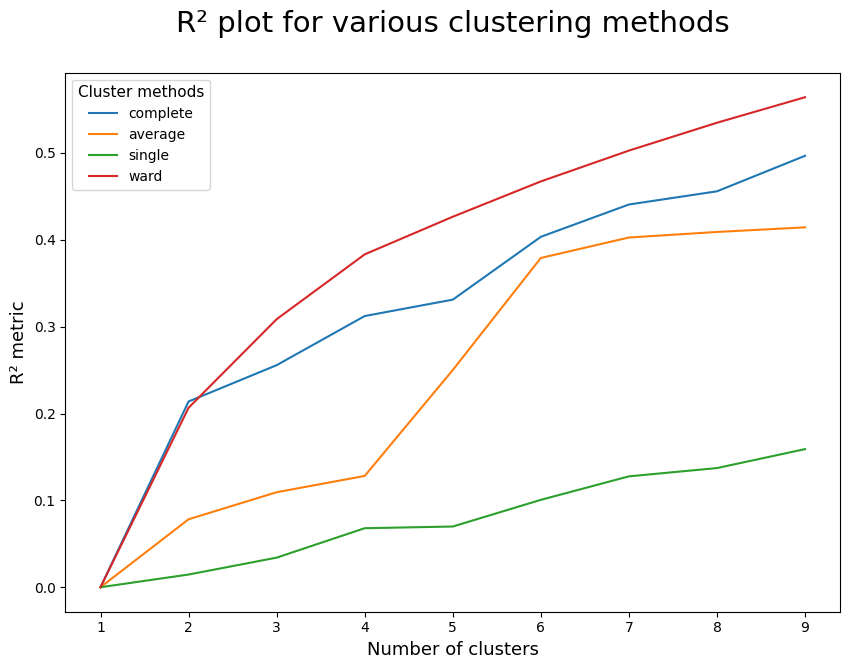

In [110]:
# Data behavior Perspective
r2_plot(df_centroids)

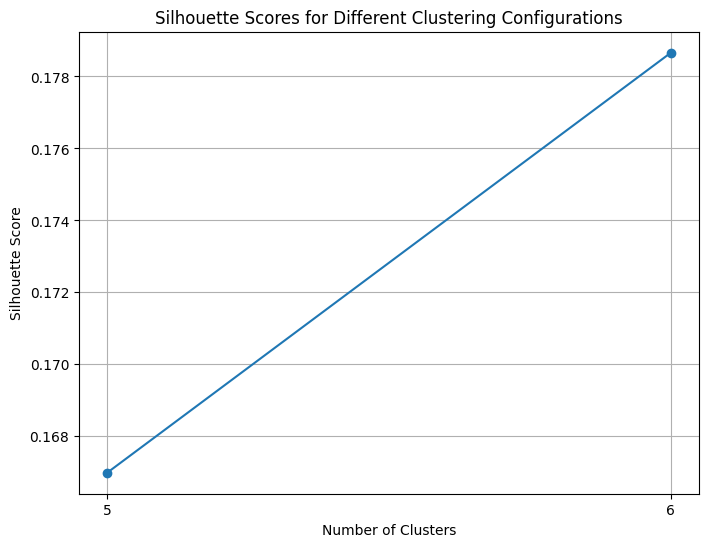

Number of Clusters: 5, Silhouette Score: 0.1670
Number of Clusters: 6, Silhouette Score: 0.1787


In [111]:
# Define your dataset and cluster numbers
X = df_centroids
n_clusters_list = [5, 6]  # Specify the cluster numbers to evaluate

# Call the function
silhouette_scores = calculate_and_plot_silhouette(X, n_clusters_list, linkage="ward")

# Print the silhouette scores
for n_clusters, score in zip(n_clusters_list, silhouette_scores):
    print(f"Number of Clusters: {n_clusters}, Silhouette Score: {score:.4f}")

# Hierarchical Clustering

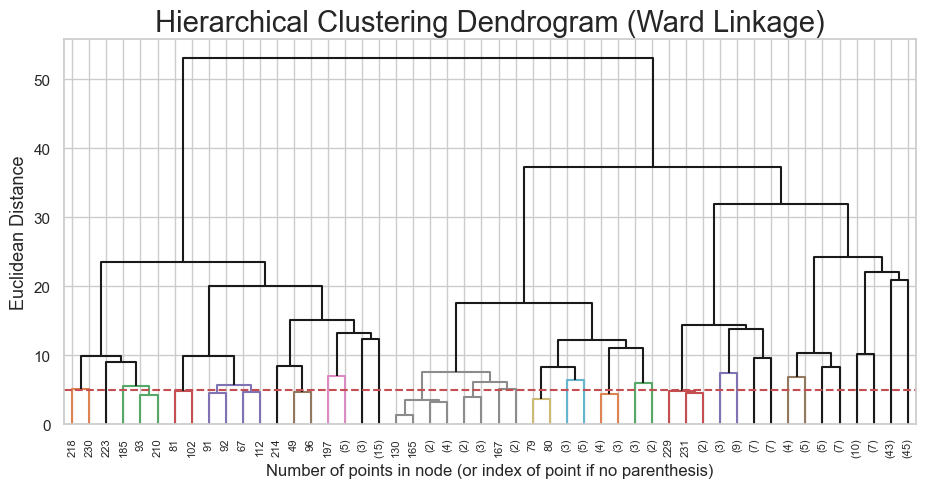

In [113]:
agglom_clustering = AgglomerativeClustering(
    linkage='ward',
    metric='euclidean',
    distance_threshold=0,
    n_clusters=None
)

cluster_labels = agglom_clustering.fit_predict(df_centroids)

# Create counts of samples under each node for dendrogram
counts = np.zeros(agglom_clustering.children_.shape[0])
n_samples = len(agglom_clustering.labels_)

for i, merge in enumerate(agglom_clustering.children_):
    current_count = 0
    for child_idx in merge:
        if child_idx < n_samples:
            current_count += 1  # leaf node
        else:
            current_count += counts[child_idx - n_samples]
    counts[i] = current_count

# Create the linkage matrix
linkage_matrix = np.column_stack([agglom_clustering.children_, agglom_clustering.distances_, counts]).astype(float)

threshold = 8
# Plot the dendrogram
sns.set(style="whitegrid")
plt.figure(figsize=(11, 5))
dendrogram(linkage_matrix, truncate_mode='level', p=5, color_threshold=threshold, above_threshold_color='k')

plt.hlines(5, 0, plt.gca().get_xlim()[1], colors="r", linestyles="dashed")
plt.title(f'Hierarchical Clustering Dendrogram (Ward Linkage)', fontsize=21)
plt.xlabel('Number of points in node (or index of point if no parenthesis)')
plt.ylabel('Euclidean Distance', fontsize=13)
plt.show()

In [114]:
# Perform hierarchical clustering on the centroids
hierarchical_clust = AgglomerativeClustering(
    linkage='ward',
    metric='euclidean',
    n_clusters=6
)

# Fit the model and predict cluster labels
cluster_labels = hierarchical_clust.fit_predict(df_centroids)

# Add the cluster labels to your centroids DataFrame
df_centroids['ClusterLabel'] = cluster_labels
df_centroids

vendor_count  \
behaviorCluster CuisineCluster SpendingCluster VendorCluster                 
0               0              0               0                 -0.667313   
                                               1                  0.105457   
                               1               0                 -0.691952   
                                               1                  0.138089   
                               2               0                 -0.675038   
...                                                                    ...   
5               3              1               3                  1.235139   
                               2               1                  0.893125   
                                               2                  3.059213   
                                               3                  1.807696   
                               3               3                  0.459908   

                                                              product_count  \
behaviorCluster CuisineCluster SpendingCluster VendorCluster                  
0               0              0               0                  -0.759774   
                                               1                  -0.347304   
                               1               0                  -0.771435   
                                               1                  -0.356340   
                               2               0                  -0.762480   
...                                                                     ...   
5               3              1               3                   1.944629   
                               2               1                   1.234068   
                                               2                   4.848093   
                                               3                   2.364893   
                               3               3                   1.857176   

                                                              is_chain  \
behaviorCluster CuisineCluster SpendingCluster VendorCluster             
0               0              0               0             -0.533675   
                                               1              0.130989   
                               1               0             -0.497791   
                                               1              0.185867   
                               2               0             -0.608942   
...                                                                ...   
5               3              1               3              1.167479   
                               2               1              0.170838   
                                               2              3.046333   
                                               3              0.521508   
                               3               3              0.521508   

                                                              Orders on Weekend  \
behaviorCluster CuisineCluster SpendingCluster VendorCluster                      
0               0              0               0                      -0.534357   
                                               1                      -0.142770   
                               1               0                      -0.527677   
                                               1                      -0.237003   
                               2               0                      -0.515080   
...                                                                         ...   
5               3              1               3                       1.335713   
                               2               1                      -0.094029   
                                               2                       1.907610   
                                               3                       1.494573   
                               3               3            

In [115]:
# Group by cluster labels including ClusterLabel and calculate the mean for metric features
df_centroids = df_centroids.groupby(['behaviorCluster',
                                     'CuisineCluster',
                                     'SpendingCluster',
                                     'VendorCluster',
                                    'ClusterLabel'])[metric_features].mean().reset_index()
df_centroids

,behaviorCluster,CuisineCluster,SpendingCluster,VendorCluster,ClusterLabel,vendor_count,product_count,is_chain,Orders on Weekend,Orders on week,...,Snacks & Beverages,Other Cuisine,total_amount_spent,order_frequency,American_ratio,Asian_ratio,European_ratio,Snacks_Beverages_ratio,Other_Cuisine_ratio,avg_vendor_use
0,0,0,0,0,0,-0.667313,-0.759774,-0.533675,-0.534357,-0.658735,...,0.227331,-0.442672,-0.615038,-1.277346,-0.427954,-0.887031,-0.373584,2.340705,-0.536658,1.170621
1,0,0,0,1,0,0.105457,-0.347304,0.130989,-0.142770,-0.197487,...,0.362008,-0.407419,-0.454239,-0.863173,-0.231917,-0.641225,-0.285331,1.660807,-0.411974,0.977389
2,0,0,1,0,0,-0.691952,-0.771435,-0.497791,-0.527677,-0.683446,...,-0.427489,-0.259285,-0.730709,-1.326386,1.457326,-0.934702,-0.347164,-0.508683,0.699428,1.169664
3,0,0,1,1,0,0.138089,-0.356340,0.185867,-0.237003,-0.120187,...,-0.401763,-0.083958,-0.665938,-0.706321,0.465566,-0.492021,-0.285204,-0.345163,0.789853,1.095267
4,0,0,2,0,0,-0.675038,-0.762480,-0.608942,-0.515080,-0.675452,...,-0.424679,-0.439677,-0.599802,-1.290505,-0.426620,1.351472,-0.358240,-0.519164,-0.534879,1.164782
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
228,5,3,1,3,3,1.235139,1.944629,1.167479,1.335713,1.575082,...,-0.161272,4.478137,1.083388,0.824830,-0.334433,-0.705831,-0.188561,-0.424786,1.758576,-1.100355
229,5,3,2,1,3,0.893125,1.234068,0.170838,-0.094029,1.201910,...,0.712919,3.245584,2.221633,-0.030353,-0.519555,0.283123,-0.389688,-0.056946,0.462963,-0.969382
230,5,3,2,2,5,3.059213,4.848093,3.046333,1.907610,4.485827,...,1.207693,4.036656,5.407605,1.268166,-0.408186,0.574204,-0.389688,-0.290208,0.229957,-1.327713
231,5,3,2,3,3,1.807696,2.364893,0.521508,1.494573,1.906791,...,0.446948,6.207208,3.154559,1.004534,-0.389661,0.032943,-0.389688,-0.281910,0.890582,-0.942006


In [116]:
# Merge df_centroids with df_clusters_combined
df_labels_merged = df_cluster.merge(df_centroids[['behaviorCluster',
                                     'CuisineCluster',
                                     'SpendingCluster',
                                     'VendorCluster',
                                     'ClusterLabel']],
                                    on=['behaviorCluster',
                                     'CuisineCluster',
                                     'SpendingCluster',
                                     'VendorCluster'])
df_labels_merged

,vendor_count,product_count,is_chain,total orders,Orders on Weekend,Orders on week,Orders in the morning,Orders in the afternoon,Orders in night,American Cuisine,...,last_promo_DISCOUNT,last_promo_FREEBIE,last_promo_No Discount,payment_method_CASH,payment_method_DIGI,behaviorCluster,CuisineCluster,SpendingCluster,VendorCluster,ClusterLabel
0,-0.406527,-0.012147,-0.530502,1,0.620842,-1.037124,-0.730228,0.066005,-0.543077,-0.443473,...,0.0,0.0,0.0,0.0,1.0,3,0,2,0,0
1,-0.406527,-0.635255,-0.179832,1,0.620842,-1.037124,0.433980,-0.783958,-0.543077,0.799132,...,1.0,0.0,0.0,0.0,1.0,0,0,1,0,0
2,-0.839745,-0.635255,-0.179832,1,0.620842,-1.037124,0.433980,-0.783958,-0.543077,0.448256,...,1.0,0.0,0.0,1.0,0.0,3,0,1,0,0
3,-0.406527,-0.427552,-0.530502,2,-0.094029,-0.663952,-0.148124,-0.358976,-0.543077,-0.443473,...,0.0,0.0,0.0,0.0,1.0,0,0,2,0,0
4,-0.406527,-0.012147,-0.881173,2,-0.094029,-0.663952,0.433980,-0.783958,-0.543077,0.968754,...,0.0,0.0,1.0,0.0,1.0,3,2,2,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
31029,-0.839745,-0.842958,-0.530502,1,-0.094029,-1.037124,-0.730228,-0.358976,-0.543077,-0.443473,...,0.0,1.0,0.0,0.0,1.0,0,0,0,0,0
31030,-0.839745,-0.842958,-0.881173,1,-0.094029,-1.037124,-0.730228,-0.358976,-0.543077,1.305091,...,0.0,0.0,0.0,0.0,1.0,0,0,1,0,0
31031,-0.839745,-0.842958,-0.530502,1,-0.094029,-1.037124,-0.730228,-0.783958,0.174903,-0.443473,...,0.0,0.0,1.0,0.0,1.0,0,0,0,0,0
31032,-0.839745,-0.842958,-0.881173,1,-0.094029,-1.037124,-0.148124,-0.783958,-0.543077,-0.443473,...,1.0,0.0,0.0,0.0,1.0,0,0,2,0,0


In [117]:
df_labels_merged.groupby('ClusterLabel')[metric_features].mean()

,vendor_count,product_count,is_chain,Orders on Weekend,Orders on week,Orders in the morning,Orders in the afternoon,Orders in night,American Cuisine,Asian Cuisine,...,Snacks & Beverages,Other Cuisine,total_amount_spent,order_frequency,American_ratio,Asian_ratio,European_ratio,Snacks_Beverages_ratio,Other_Cuisine_ratio,avg_vendor_use
ClusterLabel,,,,,,,,,,,,,,,,,,,,,
0,-0.141149,-0.178587,-0.121918,-0.125981,-0.164288,-0.093806,-0.156074,-0.054777,-0.023815,0.001399,...,-0.066438,-0.118863,-0.131953,-0.079111,0.048036,0.125828,-0.300932,0.025052,0.015209,0.083520
1,3.174537,3.343788,3.606513,2.574326,3.112691,2.157386,2.809695,1.039137,0.769266,0.843294,...,0.368670,2.021056,1.602891,1.093804,-0.062382,-0.101486,-0.162782,-0.106802,0.419584,-0.768618
2,-0.325318,-0.199699,-0.483965,-0.118056,-0.137295,-0.357286,0.266863,-0.365697,-0.232955,-0.529308,...,-0.411591,-0.328243,-0.211504,-0.095523,-0.300059,-0.841103,2.876481,-0.517928,-0.464210,-0.066416
3,0.662740,1.228564,0.623735,0.601896,1.045652,0.783654,0.980542,-0.005227,-0.027281,-0.108685,...,-0.210184,4.249260,1.077785,0.802707,-0.332541,-0.690381,-0.179500,-0.433962,1.739253,-1.118534
4,1.170615,1.256617,0.893328,0.814866,1.052011,1.002743,0.231077,1.166563,0.467151,0.350219,...,2.736042,-0.185528,1.579054,0.911928,-0.141811,-0.439761,-0.318369,1.342270,-0.401644,-0.653185
5,3.543025,4.008489,2.384923,2.514989,3.457288,2.248276,0.546824,4.409410,1.818480,3.898775,...,3.146102,0.078893,5.142230,1.150209,-0.083130,0.219693,-0.334060,0.545597,-0.481297,-0.879291


In [118]:
df_labels_merged['ClusterLabel'].value_counts()

ClusterLabel
0    25752
2     2886
1      864
4      829
3      566
5      137
Name: count, dtype: int64

In [119]:
# will work with crosstab()


# Cluster Distribution based on behaviour, Food, Expenditure, Order and then also find the Combinded results

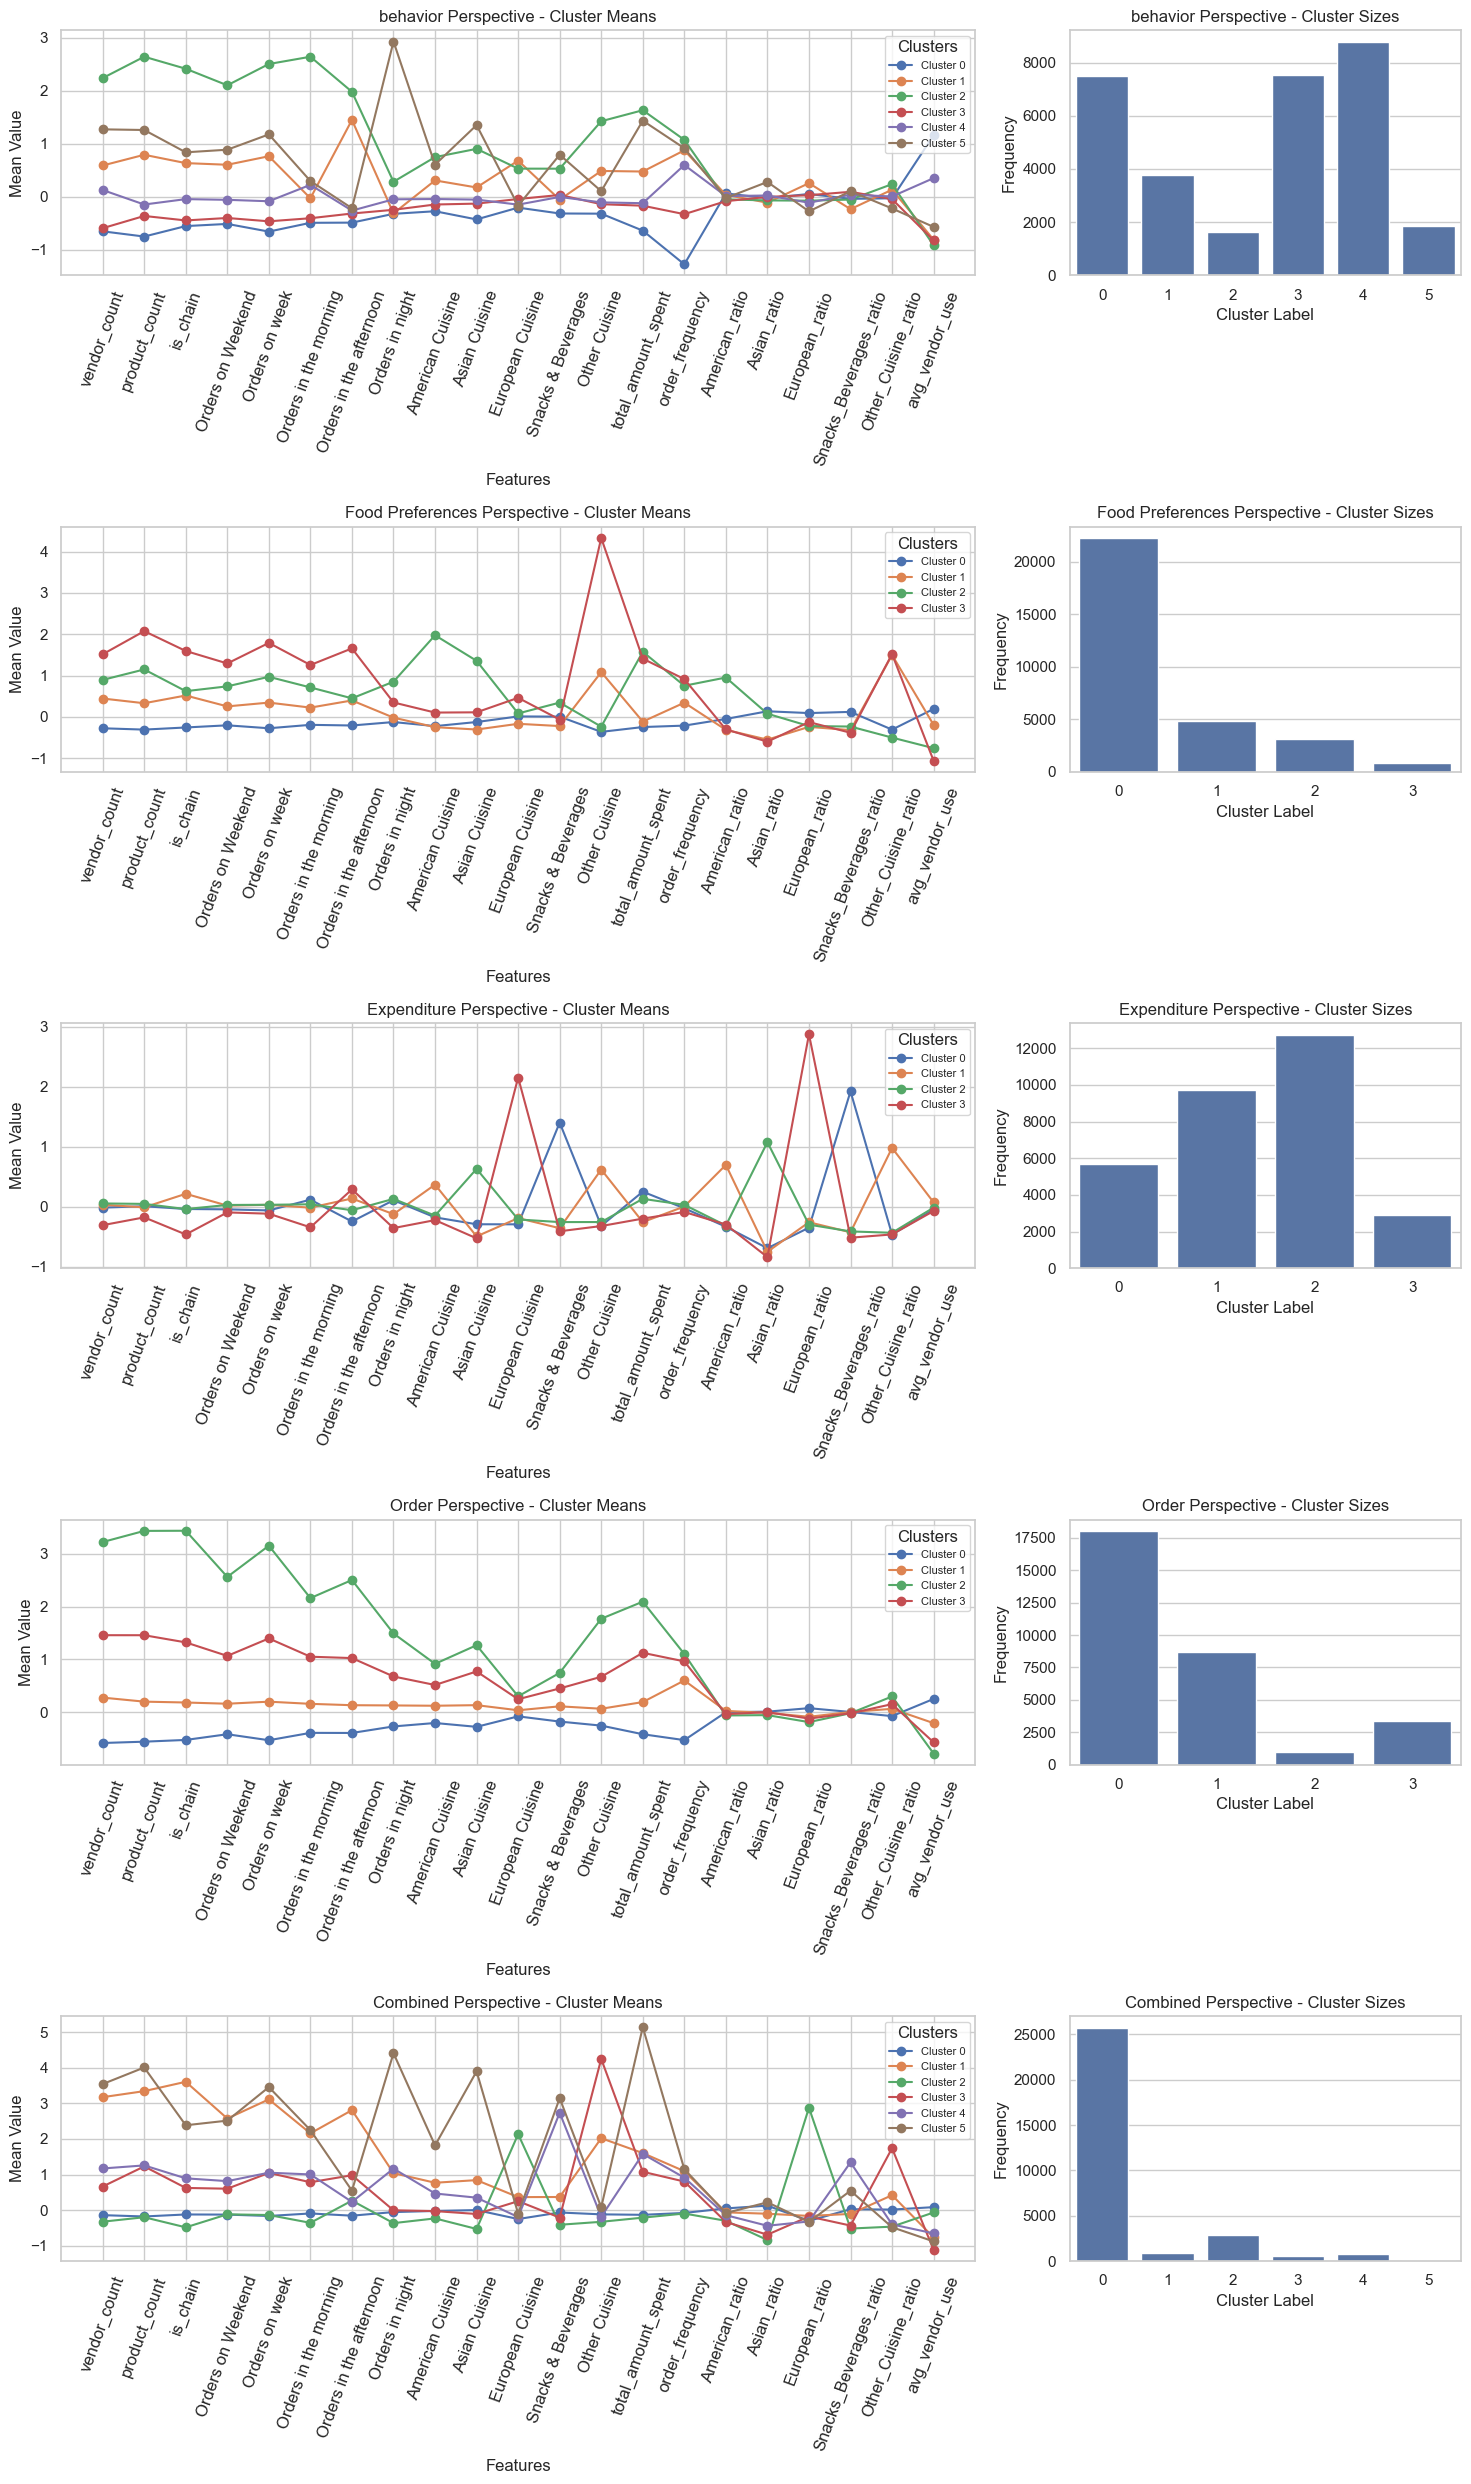

In [121]:
# Define the perspectives and corresponding cluster labels
perspective_labels = {
    'behavior Perspective': 'behaviorCluster',
    'Food Preferences Perspective': 'CuisineCluster',
    'Expenditure Perspective': 'SpendingCluster',
    'Order Perspective': 'VendorCluster',
    'Combined Perspective': 'ClusterLabel'
}

# Set the aesthetic style of the plots
sns.set_style("whitegrid")




# Determine the number of rows for the subplot grid
num_perspectives = len(perspective_labels)
fig, axs = plt.subplots(num_perspectives, 2, figsize=(15, 5 * num_perspectives),
                        gridspec_kw={'width_ratios': [7, 3]})  # Adjust the width ratios


# Loop through each perspective and create the plots
for idx, (perspective, cluster_label) in enumerate(perspective_labels.items()):
    # Calculate the mean for each cluster for the current perspective
    cluster_means = df_labels_merged.groupby(cluster_label)[metric_features].mean()

    # Line plot for cluster means on the left
    for cluster in cluster_means.index:
        axs[idx, 0].plot(metric_features, cluster_means.loc[cluster, :], marker='o', label=f'Cluster {cluster}')
    axs[idx, 0].set_title(f'{perspective} - Cluster Means')
    axs[idx, 0].set_xlabel('Features')
    axs[idx, 0].set_xticks(range(len(metric_features)))
    axs[idx, 0].set_xticklabels(metric_features, rotation=70, fontsize=12)
    axs[idx, 0].set_ylabel('Mean Value')
    axs[idx, 0].legend(title='Clusters', fontsize=8)

    # Bar plot for cluster sizes on the right
    cluster_sizes = df_labels_merged[cluster_label].value_counts().sort_index()
    sns.barplot(x=cluster_sizes.index, y=cluster_sizes.values, ax=axs[idx, 1])
    axs[idx, 1].set_title(f'{perspective} - Cluster Sizes')
    axs[idx, 1].set_xlabel('Cluster Label')
    axs[idx, 1].set_ylabel('Frequency')

# Adjust the layout for better spacing
plt.tight_layout()
plt.show()


In [122]:
df.columns


Index(['vendor_count', 'product_count', 'is_chain', 'total orders',
       'Orders on Weekend', 'Orders on week', 'Orders in the morning',
       'Orders in the afternoon', 'Orders in night', 'American Cuisine',
       'Asian Cuisine', 'European Cuisine', 'Snacks & Beverages',
       'Other Cuisine', 'total_amount_spent', 'order_frequency', 'age_group',
       'frequency_segment', 'American_ratio', 'Asian_ratio', 'European_ratio',
       'Snacks_Beverages_ratio', 'Other_Cuisine_ratio', 'avg_vendor_use',
       'last_promo_DISCOUNT', 'last_promo_FREEBIE', 'last_promo_No Discount',
       'payment_method_CASH', 'payment_method_DIGI'],
      dtype='object')

In [123]:
print(df_labels_merged.columns)


Index(['vendor_count', 'product_count', 'is_chain', 'total orders',
       'Orders on Weekend', 'Orders on week', 'Orders in the morning',
       'Orders in the afternoon', 'Orders in night', 'American Cuisine',
       'Asian Cuisine', 'European Cuisine', 'Snacks & Beverages',
       'Other Cuisine', 'total_amount_spent', 'order_frequency', 'age_group',
       'frequency_segment', 'American_ratio', 'Asian_ratio', 'European_ratio',
       'Snacks_Beverages_ratio', 'Other_Cuisine_ratio', 'avg_vendor_use',
       'last_promo_DISCOUNT', 'last_promo_FREEBIE', 'last_promo_No Discount',
       'payment_method_CASH', 'payment_method_DIGI', 'behaviorCluster',
       'CuisineCluster', 'SpendingCluster', 'VendorCluster', 'ClusterLabel'],
      dtype='object')


# Categorical Featurs distributions

In [125]:
categorical_features = ['last_promo_DISCOUNT',
    'last_promo_FREEBIE',
    'last_promo_No Discount',
    'payment_method_CASH',
    'payment_method_DIGI',
    'age_group',
    'frequency_segment']

In [126]:
# Define the features for grouping and aggregation
group_features = ['age_group', 'frequency_segment']

# Create combinations based on age group and frequency segment
promo_engagement = df_labels_merged.groupby(group_features)[
    ['last_promo_DISCOUNT', 'last_promo_FREEBIE', 'last_promo_No Discount']
].sum()

payment_method_distribution = df_labels_merged.groupby(group_features)[
    ['payment_method_CASH', 'payment_method_DIGI']
].sum()

# Aggregated metrics at the cluster level
promo_summary = df_labels_merged.groupby(['ClusterLabel', 'age_group', 'frequency_segment'])[
    ['last_promo_DISCOUNT', 'last_promo_FREEBIE', 'last_promo_No Discount']
].sum()

payment_summary = df_labels_merged.groupby(['ClusterLabel', 'age_group', 'frequency_segment'])[
    ['payment_method_CASH', 'payment_method_DIGI']
].sum()

# Add derived features
df_labels_merged['Promo_Response_By_Age'] = df_labels_merged.groupby('age_group')[
    ['last_promo_DISCOUNT', 'last_promo_FREEBIE', 'last_promo_No Discount']
].transform('mean').sum(axis=1)

df_labels_merged['Promo_Response_By_Segment'] = df_labels_merged.groupby('frequency_segment')[['last_promo_DISCOUNT', 'last_promo_FREEBIE', 'last_promo_No Discount']].transform('mean').sum(axis=1)

# df_labels_merged['Payment_Method_Trend'] = df_labels_merged.groupby('frequency_segment')[
#     ['payment_method_CASH', 'payment_method_DIGI']
# ].transform(lambda x: x.idxmax(axis=1))  # Identify most frequent payment method per row

# Summarized cluster-level combinations

promo_cluster_summary = df_labels_merged.groupby('ClusterLabel')[
    ['Promo_Response_By_Age', 'Promo_Response_By_Segment']
].mean()

payment_cluster_summary = df_labels_merged.groupby('ClusterLabel')[
    ['payment_method_CASH', 'payment_method_DIGI']
].sum()

# Display results
print("Promo Engagement by Age Group and Frequency Segment:")
print(promo_engagement)

print("\nPayment Method Distribution by Age Group and Frequency Segment:")
print(payment_method_distribution)

print("\nCluster-Level Promo Summary:")
print(promo_cluster_summary)

print("\nCluster-Level Payment Method Summary:")
print(payment_cluster_summary)


Promo Engagement by Age Group and Frequency Segment:
                             last_promo_DISCOUNT  last_promo_FREEBIE  \
age_group frequency_segment                                            
0         0                                245.0               222.0   
          1                                353.0               225.0   
          2                                149.0               137.0   
          3                                636.0               738.0   
1         0                                534.0               535.0   
          1                                679.0               463.0   
          2                                294.0               242.0   
          3                               1433.0              1656.0   
2         0                                  9.0                 9.0   
          1                                 12.0                11.0   
          2                                  5.0                 6.0   
          3

In [127]:
# Define the cuisine-related features
cuisine_features = [
    'American Cuisine',
    'Asian Cuisine',
    'European Cuisine',
    'Snacks & Beverages',
    'Other Cuisine'
]

# Aggregate cuisines for each cluster by sum and mean
df_cuisine_summed = df_labels_merged.groupby('ClusterLabel')[cuisine_features].sum()
df_cuisine_mean = df_labels_merged.groupby('ClusterLabel')[cuisine_features].mean()

# Create new aggregated features
df_labels_merged['Total_Cuisine_Orders'] = df_labels_merged[cuisine_features].sum(axis=1)
df_labels_merged['Cuisine_Diversity'] = df_labels_merged[cuisine_features].apply(lambda row: (row > 0).sum(), axis=1)

# Group by clusters for the new features
df_aggregated_cuisine = df_labels_merged.groupby('ClusterLabel')[['Total_Cuisine_Orders', 'Cuisine_Diversity']].mean()

# Display results
print("Summed Cuisine Features by Cluster:")
print(df_cuisine_summed)

print("\nMean Cuisine Features by Cluster:")
print(df_cuisine_mean)

print("\nAggregated New Cuisine Features by Cluster:")
print(df_aggregated_cuisine)


Summed Cuisine Features by Cluster:
              American Cuisine  Asian Cuisine  European Cuisine  \
ClusterLabel                                                      
0                  -613.295763      36.030274      -6442.775452   
1                   664.646140     728.605637        315.910892   
2                  -672.309557   -1527.583856       6159.440891   
3                   -15.441089     -61.515536        142.147063   
4                   387.268559     290.331277       -161.283005   
5                   249.131711     534.132204        -13.440389   

              Snacks & Beverages  Other Cuisine  
ClusterLabel                                     
0                   -1710.909786   -3060.971548  
1                     318.531194    1746.192506  
2                   -1187.851798    -947.308298  
3                    -118.964341    2405.081299  
4                    2268.178728    -153.802331  
5                     431.016003      10.808372  

Mean Cuisine Features by C

In [128]:
!pip install scikit-learn pandas matplotlib seaborn scipy

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency

# Assuming your df_labels_merged DataFrame is already loaded and preprocessed

# List of required DOW and HR columns - Updated to use existing aggregated columns
dow_columns = {'Orders on Weekend': ['Orders on Weekend'],  # Using the existing aggregated column
               'Orders on week': ['Orders on week']}  # Using the existing aggregated column
hr_columns = {'Orders in the morning': ['Orders in the morning'],  # Using the existing aggregated column
              'Orders in the afternoon': ['Orders in the afternoon'],  # Using the existing aggregated column
              'Orders in night': ['Orders in night']}  # Using the existing aggregated column

# Aggregating Order Features
def sum_existing_columns(df, column_list):
    """Helper function to sum specific columns."""
    # Check if columns exist in the DataFrame
    existing_columns = [col for col in column_list if col in df.columns]
    if existing_columns:
        return df[existing_columns].sum(axis=1)
    else:
        return 0  # Return 0 if none of the columns exist

# Add aggregated order-based features (using the updated dow_columns and hr_columns)
df_labels_merged["Orders on Weekend"] = sum_existing_columns(df_labels_merged, dow_columns['Orders on Weekend'])
df_labels_merged["Orders on Week"] = sum_existing_columns(df_labels_merged, dow_columns['Orders on week'])
df_labels_merged["Orders in the Morning"] = sum_existing_columns(df_labels_merged, hr_columns['Orders in the morning'])
df_labels_merged["Orders in the Afternoon"] = sum_existing_columns(df_labels_merged, hr_columns['Orders in the afternoon'])
df_labels_merged["Orders at Night"] = sum_existing_columns(df_labels_merged, hr_columns['Orders in night'])

# Aggregate orders by clusters
order_features = [
    "Orders on Weekend",
    "Orders on Week",
    "Orders in the Morning",
    "Orders in the Afternoon",
    "Orders at Night"
]

# Summing and averaging order features per cluster
df_orders_summed = df_labels_merged.groupby("ClusterLabel")[order_features].sum()
df_orders_mean = df_labels_merged.groupby("ClusterLabel")[order_features].mean()

# Create new aggregated features
df_labels_merged["Total_Orders"] = df_labels_merged[order_features].sum(axis=1)
df_labels_merged["Order_Diversity"] = df_labels_merged[order_features].apply(lambda row: (row > 0).sum(), axis=1)

# Grouping by clusters for the new features
df_aggregated_orders = df_labels_merged.groupby("ClusterLabel")[["Total_Orders", "Order_Diversity"]].mean()

# Displaying results
print("Summed Order Features by Cluster:")
print(df_orders_summed)

print("\nMean Order Features by Cluster:")
print(df_orders_mean)

print("\nAggregated New Order Features by Cluster:")
print(df_aggregated_orders)

Summed Order Features by Cluster:
              Orders on Weekend  Orders on Week  Orders in the Morning  \
ClusterLabel                                                             
0                  -3244.257447    -4230.734881           -2415.690224   
1                   2224.217676     2689.364773            1863.981643   
2                   -340.710867     -396.234347           -1031.127671   
3                    340.673366      591.839154             443.548309   
4                    675.523783      872.116912             831.274128   
5                    344.553489      473.648389             308.013814   

              Orders in the Afternoon  Orders at Night  
ClusterLabel                                            
0                        -4019.206815     -1410.625547  
1                         2427.576179       897.814654  
2                          770.166511     -1055.400985  
3                          554.986676        -2.958259  
4                          191.

# Cluster distributions according to cuisines

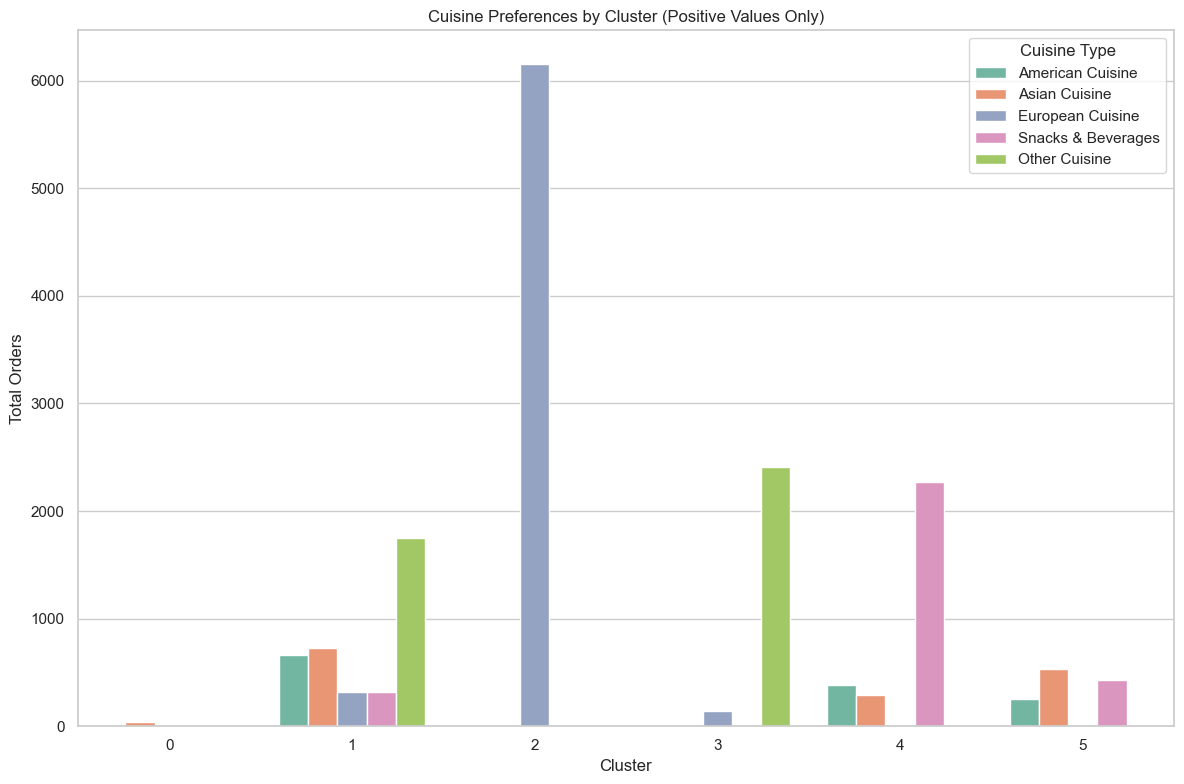

In [130]:
import matplotlib.pyplot as plt
import seaborn as sns

# Define a better color palette for clarity
colors = sns.color_palette("Set2", 5)

# Set a larger figure size
plt.figure(figsize=(12, 8))

# Define the cuisine features
cuisine_features = ['American Cuisine', 'Asian Cuisine', 'European Cuisine',
                    'Snacks & Beverages', 'Other Cuisine']

# Group and sum the values by cluster
df_melted = df_labels_merged.groupby('ClusterLabel')[cuisine_features].sum().reset_index()

# Remove negative values by setting them to NaN or zero (choose one)
df_melted[cuisine_features] = df_melted[cuisine_features].applymap(lambda x: max(x, 0))  # Replace negatives with 0

# Melt the data for better plotting
df_long = df_melted.melt(id_vars='ClusterLabel',
                         value_vars=cuisine_features,
                         var_name='Cuisine',
                         value_name='Orders')

# Use seaborn's barplot to stack the data clearly
sns.barplot(data=df_long, x='ClusterLabel', y='Orders', hue='Cuisine', palette=colors)

# Add plot title and labels
plt.title('Cuisine Preferences by Cluster (Positive Values Only)')
plt.xlabel('Cluster')
plt.ylabel('Total Orders')
plt.legend(title='Cuisine Type')

# Improve spacing and layout
plt.tight_layout()

# Display the plot
plt.show()


# Clusters distributions according to orders

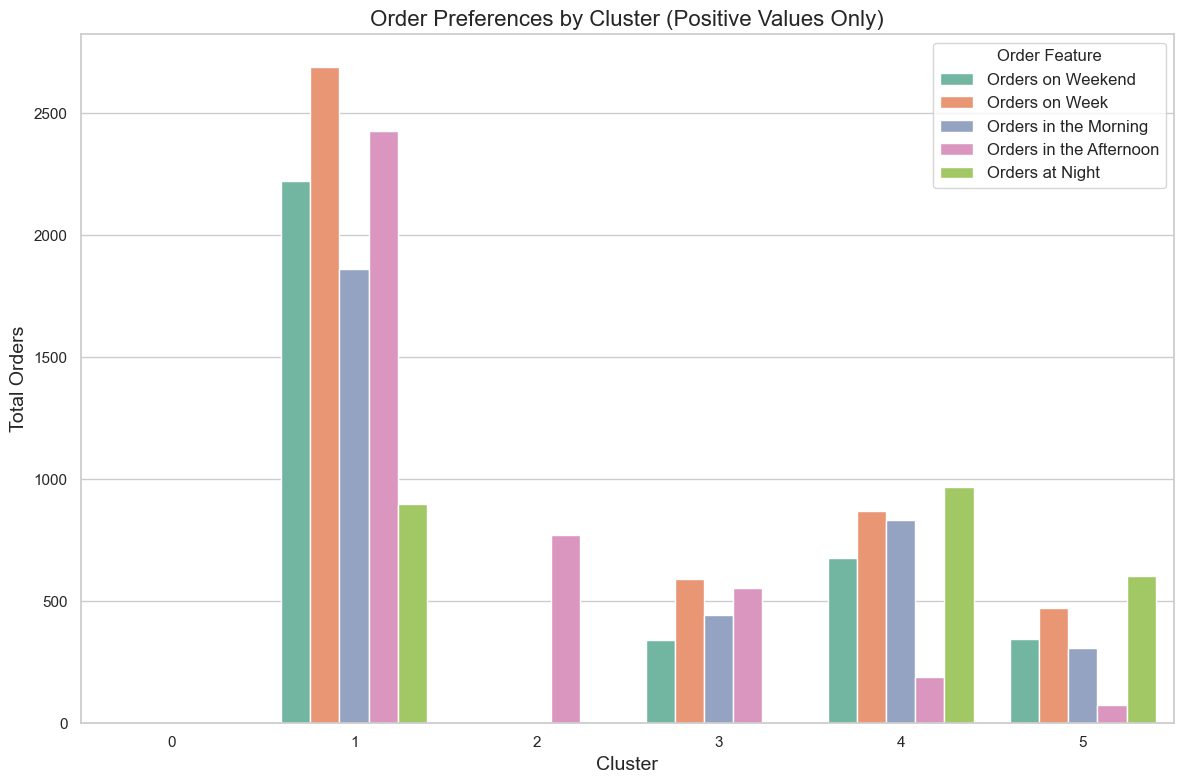

In [132]:
import matplotlib.pyplot as plt
import seaborn as sns

# Define a better color palette for clarity
colors = sns.color_palette("Set2", 5)

# Set a larger figure size
plt.figure(figsize=(12, 8))

# Define the order features
order_features = [
    "Orders on Weekend",
    "Orders on Week",
    "Orders in the Morning",
    "Orders in the Afternoon",
    "Orders at Night"
]

# Group and sum the values by cluster
df_order_melted = df_labels_merged.groupby('ClusterLabel')[order_features].sum().reset_index()

# Remove negative values by setting them to NaN or zero (choose one)
df_order_melted[order_features] = df_order_melted[order_features].applymap(lambda x: max(x, 0))  # Replace negatives with 0

# Melt the data for better plotting
df_order_long = df_order_melted.melt(id_vars='ClusterLabel',
                                     value_vars=order_features,
                                     var_name='Order Feature',
                                     value_name='Total Orders')

# Use seaborn's barplot to stack the data clearly
sns.barplot(data=df_order_long, x='ClusterLabel', y='Total Orders', hue='Order Feature', palette=colors)

# Add plot title and labels
plt.title('Order Preferences by Cluster (Positive Values Only)', fontsize=16)
plt.xlabel('Cluster', fontsize=14)
plt.ylabel('Total Orders', fontsize=14)
plt.legend(title='Order Feature', fontsize=12)

# Improve spacing and layout
plt.tight_layout()

# Display the plot
plt.show()


In [133]:
# Define the order-based features
order_features = [
    "Orders on Weekend",
    "Orders on Week",
    "Orders in the Morning",
    "Orders in the Afternoon",
    "Orders at Night"
]

# Group by ClusterLabel and age_group, then calculate the mean for each order feature
average_orders_by_age_group = df_labels_merged.groupby(['ClusterLabel', 'age_group'])[order_features].mean().unstack()




In [134]:
average_orders_by_age_group

Orders on Weekend                     Orders on Week            \
age_group                    0         1         2              0         1   
ClusterLabel                                                                  
0                    -0.137239 -0.119990 -0.155079      -0.170451 -0.161169   
1                     2.636723  2.538106  2.908429       3.037746  3.150276   
2                    -0.104884 -0.127098  0.013201      -0.138597 -0.135226   
3                     0.542781  0.635581 -0.094029       1.047494  1.056680   
4                     0.735333  0.851937  0.763816       1.112990  1.028249   
5                     2.425891  2.542058  3.480326       3.487591  3.448719   

                       Orders in the Morning                      \
age_group            2                     0         1         2   
ClusterLabel                                                       
0            -0.172557             -0.103789 -0.089415 -0.075962   
1             2.943381              2.144608  2.169403  1.908644   
2            -0.206816             -0.333109 -0.372010 -0.206334   
3            -0.104193              0.791941  0.791044 -0.293650   
4             0.828738              0.893297  1.056408  0.783243   
5             3.067772              2.413135  2.198484  0.433980   

             Orders in the Afternoon                     Orders at Night  \
age_group                          0         1         2               0   
ClusterLabel                                                               
0                          -0.155290 -0.156292 -0.163461       -0.067107   
1                           2.798263  2.798030  3.465858        0.969907   
2                           0.265129  0.270544  0.129753       -0.385776   
3                           0.920853  1.015642  0.172251        0.026355   
4                           0.273516  0.211692  0.235998        1.288332   
5                           0.320994  0.601659  4.315822        4.572528   

                                  
age_group            1         2  
ClusterLabel                      
0            -0.047724 -0.109916  
1             1.085809  0.414229  
2            -0.356865 -0.327683  
3            -0.015695 -0.363582  
4             1.113505  1.036478  
5             4.370596  1.610862

In [135]:
# Calculate descriptive statistics for two key features: Total_Orders and Cuisine_Diversity
stats = df_labels_merged.groupby('ClusterLabel')[['Total_Orders', 'Cuisine_Diversity']].describe()

# Display the result
print(stats)


             Total_Orders                                            \
                    count       mean       std       min        25%   
ClusterLabel                                                          
0                 25752.0  -0.594925  2.504767 -3.530115  -2.306980   
1                   864.0  11.693235  3.606458  4.549620   8.965237   
2                  2886.0  -0.711472  2.691879 -3.530115  -2.306980   
3                   566.0   3.406518  3.553570 -3.105134   0.722179   
4                   829.0   4.267260  2.487980 -1.351703   2.517975   
5                   137.0  13.176787  3.707427  6.876377  10.561480   

                                              Cuisine_Diversity            \
                    50%        75%        max             count      mean   
ClusterLabel                                                                
0             -1.351703   0.401728  22.112571           25752.0  1.158395   
1             11.047037  13.871216  26.494535       

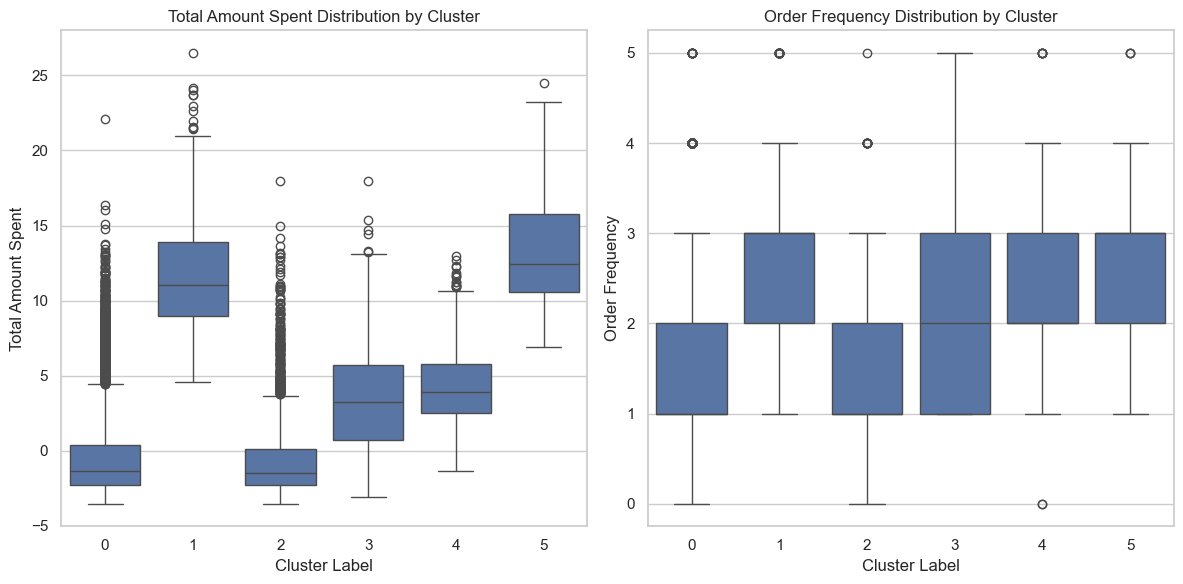

In [136]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 6))

# Boxplot for Total Amount Spent
plt.subplot(1, 2, 1)
sns.boxplot(x='ClusterLabel', y='Total_Orders', data=df_labels_merged)
plt.title('Total Amount Spent Distribution by Cluster')
plt.xlabel('Cluster Label')
plt.ylabel('Total Amount Spent')

# Boxplot for Order Frequency
plt.subplot(1, 2, 2)
sns.boxplot(x='ClusterLabel', y='Cuisine_Diversity', data=df_labels_merged)
plt.title('Order Frequency Distribution by Cluster')
plt.xlabel('Cluster Label')
plt.ylabel('Order Frequency')

plt.tight_layout()
plt.show()



# *Checked the clusters against two features Total Amount Spent and Order*

In [138]:

# Calculate descriptive statistics for two key features
stats = df_labels_merged.groupby('ClusterLabel')[['total_amount_spent', 'order_frequency']].describe()

# Display the results
print(stats)


             total_amount_spent                                          \
                          count      mean       std       min       25%   
ClusterLabel                                                              
0                       25752.0 -0.131953  0.769592 -0.940073 -0.620087   
1                         864.0  1.602891  1.478712 -0.236603  0.606537   
2                        2886.0 -0.211504  0.673942 -0.926321 -0.632962   
3                         566.0  1.077785  0.990322 -0.584158  0.385641   
4                         829.0  1.579054  1.531223 -0.803908  0.395145   
5                         137.0  5.142230  2.636120  0.490325  3.440909   

                                            order_frequency            \
                   50%       75%        max           count      mean   
ClusterLabel                                                            
0            -0.360364  0.061610   7.657145         25752.0 -0.079111   
1             1.106704  2.195074

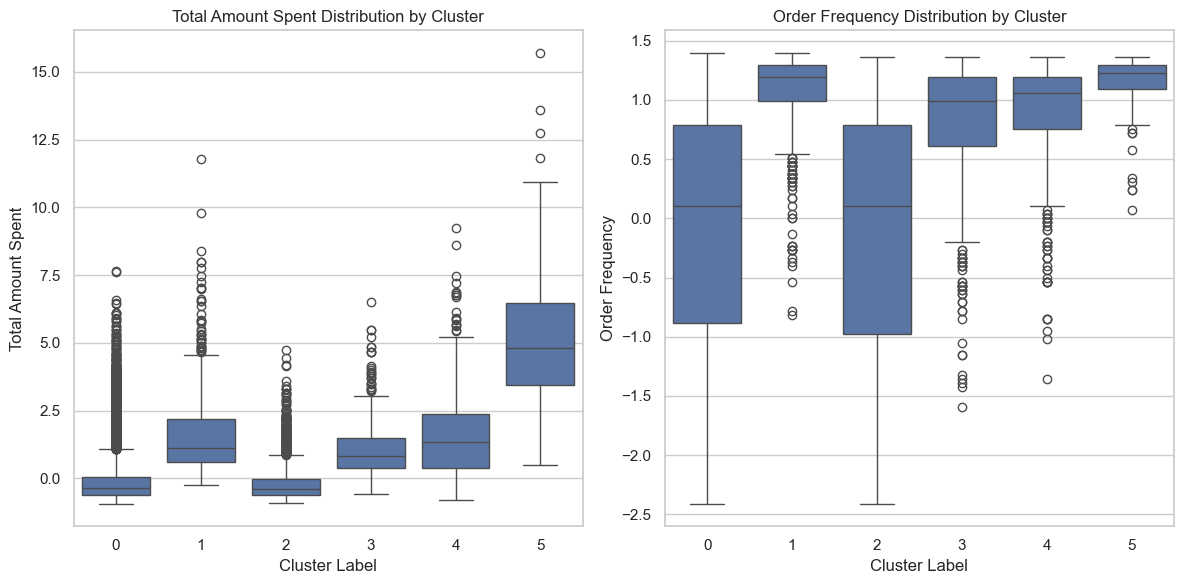

In [139]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 6))

# Boxplot for Total Amount Spent
plt.subplot(1, 2, 1)
sns.boxplot(x='ClusterLabel', y='total_amount_spent', data=df_labels_merged)
plt.title('Total Amount Spent Distribution by Cluster')
plt.xlabel('Cluster Label')
plt.ylabel('Total Amount Spent')

# Boxplot for Order Frequency
plt.subplot(1, 2, 2)
sns.boxplot(x='ClusterLabel', y='order_frequency', data=df_labels_merged)
plt.title('Order Frequency Distribution by Cluster')
plt.xlabel('Cluster Label')
plt.ylabel('Order Frequency')

plt.tight_layout()
plt.show()


In [140]:
# Assuming df_labels_merged is your DataFrame
import pandas as pd

# Defining the new features to use
promo_segments_features = ['last_promo_DISCOUNT', 'last_promo_FREEBIE', 'last_promo_No Discount']
payment_segments_features = ['payment_method_CASH', 'payment_method_DIGI']
age_segments_features = ['age_group']
frequency_segments_features = ['frequency_segment']

# Combine all the categorical feature lists into one list
categorical_features = promo_segments_features + payment_segments_features + age_segments_features + frequency_segments_features

# 1. Summing the categorical features within each cluster
df_categorical_summed = df_labels_merged.groupby('ClusterLabel')[categorical_features].sum()

# 2. Averaging the categorical features within each cluster
df_categorical_mean = df_labels_merged.groupby('ClusterLabel')[categorical_features].mean()

# Display the results
print("Summed Categorical Features by Cluster:")
print(df_categorical_summed)

print("\nAveraged Categorical Features by Cluster:")
print(df_categorical_mean)


Summed Categorical Features by Cluster:
              last_promo_DISCOUNT  last_promo_FREEBIE  last_promo_No Discount  \
ClusterLabel                                                                    
0                          3675.0              3668.0                 12801.0   
1                           108.0                94.0                   566.0   
2                           450.0               294.0                  1878.0   
3                            53.0                71.0                   367.0   
4                            84.0               120.0                   519.0   
5                            17.0                22.0                    84.0   

              payment_method_CASH  payment_method_DIGI  age_group  \
ClusterLabel                                                        
0                          4840.0               5262.0      17909   
1                            98.0                105.0        618   
2                           388.0  

In [141]:
df_categorical_summed

,last_promo_DISCOUNT,last_promo_FREEBIE,last_promo_No Discount,payment_method_CASH,payment_method_DIGI,age_group,frequency_segment
ClusterLabel,,,,,,,
0,3675.0,3668.0,12801.0,4840.0,5262.0,17909,50353
1,108.0,94.0,566.0,98.0,105.0,618,2548
2,450.0,294.0,1878.0,388.0,352.0,2004,5598
3,53.0,71.0,367.0,64.0,96.0,396,1537
4,84.0,120.0,519.0,95.0,124.0,583,2393
5,17.0,22.0,84.0,18.0,14.0,98,411


# Clusters disctibutions of the Categorical features

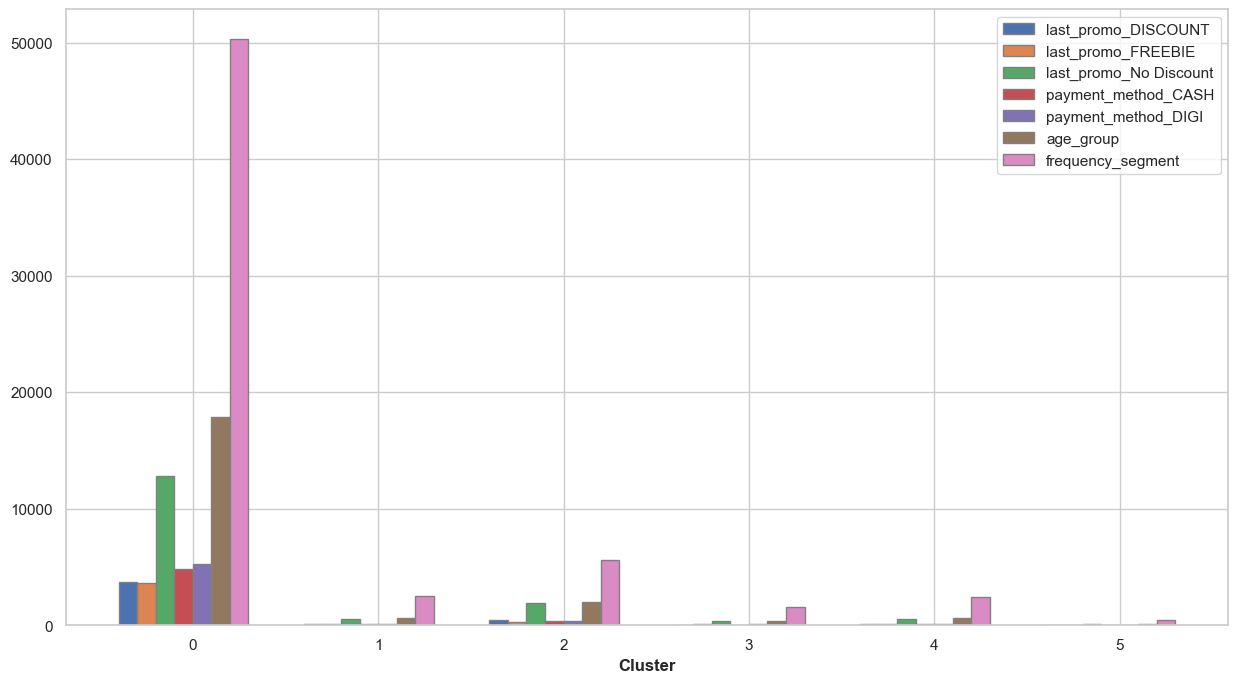

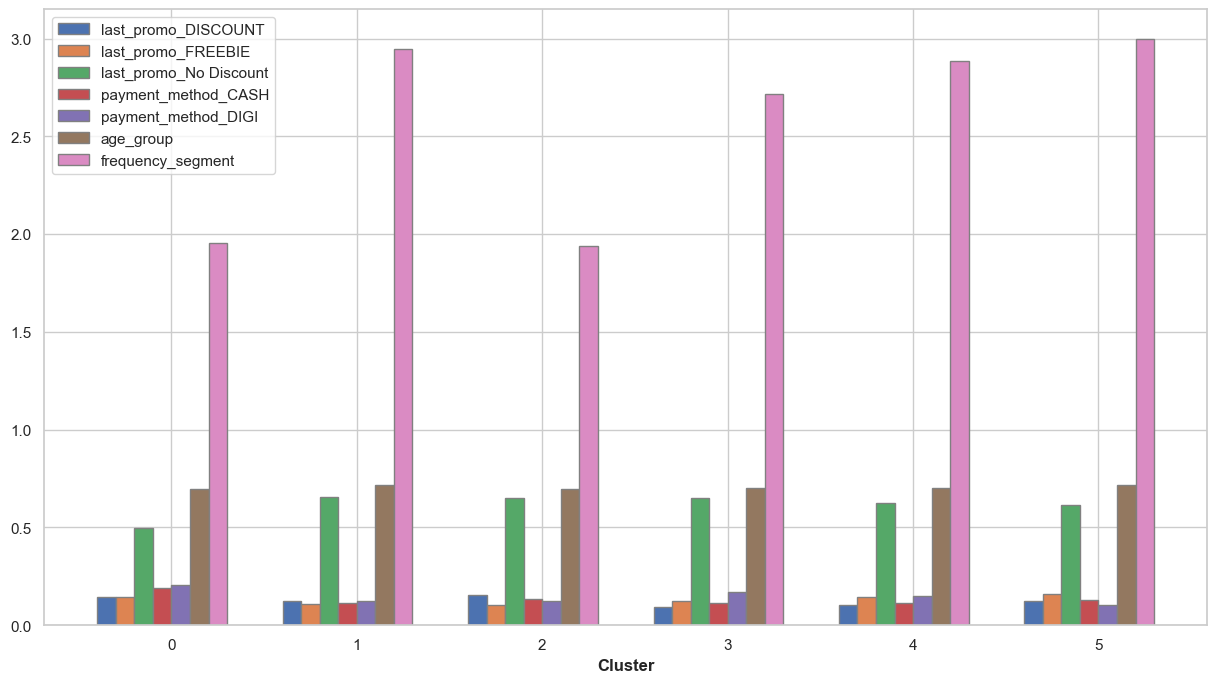

In [143]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Assuming df_categorical_summed and df_categorical_mean are already defined
# Remove negative values by setting them to 0
df_categorical_summed[df_categorical_summed < 0] = 0
df_categorical_mean[df_categorical_mean < 0] = 0

# Function to plot activities
def plot_activities(df):
    # Number of clusters
    num_clusters = len(df)

    # Setting up the bar width and positions
    barWidth = 0.1
    r = np.arange(num_clusters)

    # Plotting
    plt.figure(figsize=(15, 8))

    for idx, feature in enumerate(df.columns):
        plt.bar(r + barWidth * idx, df[feature], width=barWidth, edgecolor='grey', label=feature)

    # Add xticks on the middle of the group bars
    plt.xlabel('Cluster', fontweight='bold')
    plt.xticks([r + barWidth * len(df.columns) / 2 for r in range(len(df))], df.index)

    # Create legend & Show graphic
    plt.legend()
    plt.show()

# Example usage for summed features
plot_activities(df_categorical_summed)

# Example usage for averaged features
plot_activities(df_categorical_mean)


In [144]:
df_labels_merged

,vendor_count,product_count,is_chain,total orders,Orders on Weekend,Orders on week,Orders in the morning,Orders in the afternoon,Orders in night,American Cuisine,...,Promo_Response_By_Age,Promo_Response_By_Segment,Total_Cuisine_Orders,Cuisine_Diversity,Orders on Week,Orders in the Morning,Orders in the Afternoon,Orders at Night,Total_Orders,Order_Diversity
0,-0.406527,-0.012147,-0.530502,1,0.620842,-1.037124,-0.730228,0.066005,-0.543077,-0.443473,...,0.789735,0.652269,-1.146343,1,-1.037124,-0.730228,0.066005,-0.543077,-1.623582,2
1,-0.406527,-0.635255,-0.179832,1,0.620842,-1.037124,0.433980,-0.783958,-0.543077,0.799132,...,0.789735,0.652269,-0.827302,1,-1.037124,0.433980,-0.783958,-0.543077,-1.309337,2
2,-0.839745,-0.635255,-0.179832,1,0.620842,-1.037124,0.433980,-0.783958,-0.543077,0.448256,...,0.806865,0.652269,-1.440587,1,-1.037124,0.433980,-0.783958,-0.543077,-1.309337,2
3,-0.406527,-0.427552,-0.530502,2,-0.094029,-0.663952,-0.148124,-0.358976,-0.543077,-0.443473,...,0.806865,0.652269,-1.036287,1,-0.663952,-0.148124,-0.358976,-0.543077,-1.808158,0
4,-0.406527,-0.012147,-0.881173,2,-0.094029,-0.663952,0.433980,-0.783958,-0.543077,0.968754,...,0.789735,0.652269,0.758261,2,-0.663952,0.433980,-0.783958,-0.543077,-1.651036,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
31029,-0.839745,-0.842958,-0.530502,1,-0.094029,-1.037124,-0.730228,-0.358976,-0.543077,-0.443473,...,0.806865,0.652269,-1.211840,1,-1.037124,-0.730228,-0.358976,-0.543077,-2.763435,0
31030,-0.839745,-0.842958,-0.881173,1,-0.094029,-1.037124,-0.730228,-0.358976,-0.543077,1.305091,...,0.806865,0.652269,-0.583751,1,-1.037124,-0.730228,-0.358976,-0.543077,-2.763435,0
31031,-0.839745,-0.842958,-0.530502,1,-0.094029,-1.037124,-0.730228,-0.783958,0.174903,-0.443473,...,0.806865,0.652269,-1.227367,1,-1.037124,-0.730228,-0.783958,0.174903,-2.470437,1
31032,-0.839745,-0.842958,-0.881173,1,-0.094029,-1.037124,-0.148124,-0.783958,-0.543077,-0.443473,...,0.806865,0.652269,-1.838297,0,-1.037124,-0.148124,-0.783958,-0.543077,-2.606312,0


# Additional analysis
# Comparison of different clusters

The file is commented cause it takes much time, but it's figure is given on the report. (Time takes minimum 31 minutes & 57 seconds,  that's why commented). It was done to check and giving answers why we chose k-means cause it was showing good results according to other clusters. Uncommenting the code will show the result.

In [146]:


# import numpy as np
# import pandas as pd
# from sklearn.cluster import KMeans, AgglomerativeClustering
# from sklearn.metrics import pairwise_distances
# import matplotlib.pyplot as plt
# import pandas as pd
# file_path = '/content/drive/MyDrive/Colab Notebooks/data_save_for_clustering.csv'
# df = pd.read_csv(file_path)
# X = df.select_dtypes(include=[np.number]).values


# def calculate_r_squared(X, labels, centroids):
#     total_variance = np.sum(pairwise_distances(X, X.mean(axis=0).reshape(1, -1)) ** 2)
#     within_cluster_variance = sum(
#         np.sum(pairwise_distances(X[labels == i], centroid.reshape(1, -1)) ** 2)
#         for i, centroid in enumerate(centroids)
#     )
#     return 1 - (within_cluster_variance / total_variance)


# n_clusters_range = range(2, 10)
# algorithms = {
#     'K-Means': lambda n_clusters: KMeans(n_clusters=n_clusters, random_state=42),
#     'Ward (Agglomerative)': lambda n_clusters: AgglomerativeClustering(n_clusters=n_clusters, linkage='ward'),
#     'Complete Linkage': lambda n_clusters: AgglomerativeClustering(n_clusters=n_clusters, linkage='complete'),
# }


# r_squared_scores = {alg_name: [] for alg_name in algorithms.keys()}

# for n_clusters in n_clusters_range:
#     for alg_name, alg_func in algorithms.items():
#         algo = alg_func(n_clusters)
#         labels = algo.fit_predict(X)

#         if alg_name == 'K-Means':
#             centroids = algo.cluster_centers_
#         else:
#             # Compute centroids for Agglomerative Clustering
#             centroids = np.array([X[labels == i].mean(axis=0) for i in range(n_clusters)])

#         r_squared = calculate_r_squared(X, labels, centroids)
#         r_squared_scores[alg_name].append(r_squared)

# # Plot the R-Squared values for all algorithms
# plt.figure(figsize=(10, 6))
# for alg_name, scores in r_squared_scores.items():
#     plt.plot(n_clusters_range, scores, marker='o', label=alg_name)

# plt.title('R-Squared Values for Different Clustering Algorithms')
# plt.xlabel('Number of Clusters')
# plt.ylabel('R-Squared')
# plt.legend()
# plt.grid(True)
# plt.show()


In [147]:




# Group by 'ClusterLabel' and the chosen categorical feature, then compute the mean for activity features
average_income_by_categorical = df_labels_merged.groupby(['ClusterLabel','payment_method_CASH' ])[categorical_features].mean().unstack()

# Display the result
print(average_income_by_categorical)


                    last_promo_DISCOUNT           last_promo_FREEBIE  \
payment_method_CASH                 0.0       1.0                0.0   
ClusterLabel                                                           
0                              0.136907  0.167769           0.143506   
1                              0.125326  0.122449           0.107050   
2                              0.156125  0.154639           0.101281   
3                              0.093625  0.093750           0.123506   
4                              0.098093  0.126316           0.137602   
5                              0.126050  0.111111           0.159664   

                              last_promo_No Discount            \
payment_method_CASH       1.0                    0.0       1.0   
ClusterLabel                                                     
0                    0.137810               0.518124  0.406198   
1                    0.122449               0.657963  0.632653   
2                    

In [148]:
# Define the categorical features lists
promo_segments_features = ['last_promo_DISCOUNT', 'last_promo_FREEBIE', 'last_promo_No Discount']
payment_segments_features = ['payment_method_CASH', 'payment_method_DIGI']
age_segments_features = ['age_group']
frequency_segments_features = ['frequency_segment']

# List of all categorical features to iterate over
categorical_features = promo_segments_features + payment_segments_features + age_segments_features + frequency_segments_features

# Instead of 'Dropout', 'SameDayEnrollmentFlag', 'UseByTime', use available numerical features.
# Here, I'm using the first three numerical features from your df_labels_merged DataFrame
# Replace with your desired numerical features.
numerical_features = df_labels_merged.select_dtypes(include=['number']).columns[:3]

# Iterate over each categorical feature and compute the mean for the selected numerical features
for feature in categorical_features:
    average_other_features_by_categorical = df_labels_merged.groupby(['ClusterLabel', feature])[numerical_features].mean().unstack()

    # Print the result for each categorical feature
    print(f"Average other features by cluster and {feature}:")
    print(average_other_features_by_categorical)
    print("\n" + "-"*50 + "\n")

Average other features by cluster and last_promo_DISCOUNT:
                    vendor_count           product_count            is_chain  \
last_promo_DISCOUNT          0.0       1.0           0.0       1.0       0.0   
ClusterLabel                                                                   
0                      -0.126938 -0.226521     -0.159967 -0.290441 -0.114867   
1                       3.155484  3.307912      3.357525  3.247629  3.631618   
2                      -0.323298 -0.336250     -0.196829 -0.215234 -0.487748   
3                       0.660049  0.688778      1.234068  1.175284  0.635664   
4                       1.165849  1.212881      1.258881  1.236541  0.881121   
5                       3.557413  3.441464      4.072670  3.555450  2.388827   

                               
last_promo_DISCOUNT       1.0  
ClusterLabel                   
0                   -0.164279  
1                    3.430772  
2                   -0.463485  
3                    0.50827